In [2]:
import numpy as np
import pandas as pd
from pathlib import Path
from astropy.io import fits
from astropy.wcs import WCS
import astropy.units as u
import astropy.constants as c
import pyneb as pn
import matplotlib.pyplot as plt
HAS_PYNEB=True
from astropy.coordinates import SkyCoord, SkyOffsetFrame
from scipy.stats import linregress
from astropy.visualization import AsinhStretch, PercentileInterval
from skimage.segmentation import find_boundaries
from matplotlib import cm
from skimage.measure import find_contours
from matplotlib.patches import ConnectionPatch
from scipy.optimize import curve_fit
import os
import re
import matplotlib as mpl
import seaborn as sns

plt.rcParams["text.usetex"] = False

plt.rc('text', usetex=True)
plt.rc('font', family='serif', size=20)

#add rc param for ticks are inwards and minor ticks are on
plt.rc('xtick', direction='in', top=True)
plt.rc('ytick', direction='in', right=True)

cmap = cm.get_cmap('magma')


/var/folders/90/nb83zn5j00bc53x6bcv0jcwm0000gn/T/ipykernel_40651/3572512607.py:33: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = cm.get_cmap('magma')


In [262]:
# load in the HII region catalog
cat_path = 'CATALOGS/flux_catalogs/total_flux_catalog_with_derived.csv'
cat = pd.read_csv(cat_path)
# print all column names
for col in cat.columns:
    print(col)

region_id
npix_region
npix_edge_ring
F_Halpha_sum
F_Halpha_e_sum
SNR_Halpha_sum
Halpha_b_edge
F_Hbeta_sum
F_Hbeta_e_sum
SNR_Hbeta_sum
Hbeta_b_edge
F_[OIII]5007_sum
F_[OIII]5007_e_sum
SNR_[OIII]5007_sum
[OIII]5007_b_edge
F_[SII]6716_sum
F_[SII]6716_e_sum
SNR_[SII]6716_sum
[SII]6716_b_edge
F_[SII]6731_sum
F_[SII]6731_e_sum
SNR_[SII]6731_sum
[SII]6731_b_edge
F_[NII]6583_sum
F_[NII]6583_e_sum
SNR_[NII]6583_sum
[NII]6583_b_edge
F_[OII]3727_sum
F_[OII]3727_e_sum
SNR_[OII]3727_sum
[OII]3727_b_edge
field
y
x
removed_by_saddle
removed_by_edge
kind
center_x_px
center_y_px
zoi_center_label
bg_local
sigma_local
radius_p16_px
radius_p50_px
radius_p84_px
radius_p16_pc
radius_p50_pc
radius_p84_pc
radius_areaeq_px
radius_areaeq_pc
boundary_method
area_px_after_carve
radius_areaeq_px_after_carve
radius_areaeq_pc_after_carve
id_int
x_int
y_int
FIELD_int
F_[OII]3727_int
F_[OII]3727_e_int
SNR_[OII]3727_int
F_Hbeta_int
F_Hbeta_e_int
SNR_Hbeta_int
F_[OIII]4959_int
F_[OIII]4959_e_int
SNR_[OIII]4959_int
F_[OI

In [4]:
# load in the WR and SNR catalogs
wr_catalog = pd.read_csv('CATALOGS/WR_catalog.csv', sep='\t')
snr_catalog = pd.read_csv('CATALOGS/snr_table.csv')
rows = []
with open("CATALOGS/snr_table.csv", "r") as f:
    for line in f:
        # Remove LaTeX and dollar symbols
        clean = re.sub(r"\\rm|\\pm|\$", "", line)
        # Split by comma
        parts = [p.strip() for p in clean.split(",") if p.strip()]
        # Find any token that looks like an RA (contains colons) and a Dec (starts with + or -)
        ra, dec = None, None
        for p in parts:
            if ":" in p and ra is None:
                ra = p
            elif (p.startswith("+") or p.startswith("-")) and ":" in p and dec is None:
                dec = p
        if ra and dec:
            rows.append((ra, dec))

# Make a DataFrame
snr_catalog = pd.DataFrame(rows, columns=["RA", "Dec"])

In [5]:
def field_to_fieldnum(field_label: str) -> str:
    """
    Map your plot field labels to WR catalog Field codes.
    Input examples: 'NE','NW','SE','SW','F5'...'F9'
    Output: 'F1'...'F9'
    """
    mapping = {"NE": "F1", "NW": "F2", "SE": "F3", "SW": "F4"}
    return mapping.get(field_label, field_label)  # F5->F5 etc.


def parse_name_to_coords(name: str) -> SkyCoord:
    # Example: 'J013307.80+302951.1'
    ra_h = name[1:3]
    ra_m = name[3:5]
    ra_s = name[5:10]
    dec_sign = name[10]
    dec_d = name[11:13]
    dec_m = name[13:15]
    dec_s = name[15:]
    ra_str = f"{ra_h}h{ra_m}m{ra_s}s"
    dec_str = f"{dec_sign}{dec_d}d{dec_m}m{dec_s}s"
    return SkyCoord(ra_str, dec_str, frame="icrs")

# ha_fits_path = "M33_Halpha.fits"
def load_halpha_log_and_wcs(wcs: str):
    with fits.open(wcs) as hdul:
        data = hdul[0].data
        hdr = hdul[0].header

    data = np.where(np.isfinite(data), data, np.nan)

    with np.errstate(divide="ignore", invalid="ignore"):
        ha_log = np.log10(data)
    ha_log = np.where(np.isfinite(ha_log), ha_log, np.nan)

    wcs = WCS(hdr)
    return ha_log, wcs


def try_load_boundary_map(field_label: str, boundary_dir="boundary_map"):
    """
    Tries boundary_map/Boundary_map_{FIELD}.fits where FIELD is e.g. NE, NW, SE, SW, F5...
    Returns array or None if missing/unreadable.
    """
    path = os.path.join(boundary_dir, f"Boundary_map_{field_label}.fits")
    if not os.path.exists(path):
        return None
    try:
        return fits.getdata(path)
    except Exception:
        return None


def get_wr_pixels_for_field(wr_catalog: pd.DataFrame, field_num: str, wcs: WCS):
    wr_field = wr_catalog[wr_catalog["Field"] == field_num]
    if len(wr_field) == 0:
        return np.array([]), np.array([])

    coords = [parse_name_to_coords(n) for n in wr_field["Name (star)"]]
    sky = SkyCoord(coords)
    x_wr, y_wr = wcs.world_to_pixel(sky)
    return np.array(x_wr), np.array(y_wr)


def get_snr_pixels_for_field(snr_catalog: pd.DataFrame, wcs: WCS, xlim=(50, 2000), ylim=(50, 2000)):
    """
    Your snr_table.csv loaded with pd.read_csv.
    This assumes columns named exactly 'RA' and 'Dec' OR 'Dec'/'DEC' variants.
    """
    # Be forgiving about Dec column name
    if "Dec" in snr_catalog.columns:
        dec_col = "Dec"
    elif "DEC" in snr_catalog.columns:
        dec_col = "DEC"
    elif "dec" in snr_catalog.columns:
        dec_col = "dec"
    else:
        raise KeyError("SNR catalog must have a Dec/DEC column (plus RA).")

    if "RA" not in snr_catalog.columns:
        raise KeyError("SNR catalog must have an 'RA' column.")

    coords = SkyCoord(snr_catalog["RA"].astype(str),
                      snr_catalog[dec_col].astype(str),
                      unit=(u.hourangle, u.deg))

    x_snr, y_snr = wcs.world_to_pixel(coords)
    x_snr = np.array(x_snr)
    y_snr = np.array(y_snr)

    in_field = (x_snr > xlim[0]) & (x_snr < xlim[1]) & (y_snr > ylim[0]) & (y_snr < ylim[1])
    return x_snr[in_field], y_snr[in_field]


In [6]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import cm, colors
from astropy.io import fits
from skimage.segmentation import find_boundaries


def _first_existing_path(paths):
    for p in paths:
        if p and os.path.exists(p):
            return p
    return None


def _build_region_color_mapper(
    catalog,
    color_regions_by=None,
    default_color="k",
    categorical_colors=None,
    numeric_cmap="viridis",
    numeric_vmin=None,
    numeric_vmax=None,
    unclassified_color="#888888",
):
    """
    Returns:
        get_color(row) -> matplotlib color
        legend_info -> dict with metadata for optional legend / colorbar use
    """
    if color_regions_by is None:
        return (lambda row: default_color), {"mode": "constant"}

    if color_regions_by not in catalog.columns:
        raise ValueError(
            f"Column '{color_regions_by}' not found in catalog. "
            f"Available columns: {list(catalog.columns)}"
        )

    values = catalog[color_regions_by]

    # Treat strings / mixed objects / booleans as categorical
    is_categorical = (
        pd.api.types.is_object_dtype(values)
        or pd.api.types.is_string_dtype(values)
        or pd.api.types.is_bool_dtype(values)
        or pd.api.types.is_categorical_dtype(values)
    )

    if is_categorical:
        unique_vals = pd.Series(values.fillna("Unclassified")).astype(str).unique()

        if categorical_colors is None:
            # default palette for common BPT-like classes
            default_cat_colors = {
                "Star-forming": "blue",
                "Composite": "green",
                "AGN/Shock": "red",
                "Unclassified": "blue",
                "nan": unclassified_color,
            }

            # assign default colors to known values; others from tab20
            fallback_cmap = plt.get_cmap("tab20")
            fallback_vals = [v for v in unique_vals if v not in default_cat_colors]
            fallback_map = {
                v: fallback_cmap(i / max(1, len(fallback_vals) - 1))
                for i, v in enumerate(fallback_vals)
            }

            categorical_colors = {**default_cat_colors, **fallback_map}

        def get_color(row):
            val = row.get(color_regions_by, "Unclassified")
            if pd.isna(val):
                val = "Unclassified"
            return categorical_colors.get(str(val), unclassified_color)

        return get_color, {
            "mode": "categorical",
            "column": color_regions_by,
            "categorical_colors": categorical_colors,
        }

    # otherwise treat as numeric
    vals_num = pd.to_numeric(values, errors="coerce")
    finite = vals_num[np.isfinite(vals_num)]
    if finite.empty:
        return (lambda row: default_color), {"mode": "constant"}

    if numeric_vmin is None:
        numeric_vmin = np.nanmin(finite)
    if numeric_vmax is None:
        numeric_vmax = np.nanmax(finite)

    norm = colors.Normalize(vmin=numeric_vmin, vmax=numeric_vmax)
    cmap = plt.get_cmap(numeric_cmap)

    def get_color(row):
        val = pd.to_numeric(row.get(color_regions_by, np.nan), errors="coerce")
        if not np.isfinite(val):
            return unclassified_color
        return cmap(norm(val))

    return get_color, {
        "mode": "numeric",
        "column": color_regions_by,
        "cmap": cmap,
        "norm": norm,
    }


def _plot_labelmap_boundaries(
    ax,
    label_map,
    catalog=None,
    region_id_col="region_id",
    color_regions_by=None,
    default_color="k",
    lw=0.5,
    alpha=0.9,
    categorical_colors=None,
    numeric_cmap="viridis",
    numeric_vmin=None,
    numeric_vmax=None,
    zorder=2,
    draw_background_outline=False,
    background_outline_color="k",
    background_outline_lw=None,
    background_outline_alpha=None,
):
    label_int = np.rint(np.nan_to_num(label_map, nan=0)).astype(np.int32)
    print("label_map dtype:", label_map.dtype)
    print("label_int dtype:", label_int.dtype)
    print("label_map min/max:", np.nanmin(label_map), np.nanmax(label_map))
    print("unique labels (first 30):", np.unique(label_int)[:30])
    print("number of unique labels:", len(np.unique(label_int)))

    if draw_background_outline:
        ax.contour(
            (label_int > 0).astype(float),
            levels=[0.5],
            colors=[background_outline_color],
            linewidths=(lw if background_outline_lw is None else background_outline_lw),
            origin="lower",
            zorder=zorder,
            alpha=(alpha if background_outline_alpha is None else background_outline_alpha),
        )

    if catalog is None or region_id_col not in catalog.columns:
        ax.contour(
            (label_int > 0).astype(float),
            levels=[0.5],
            colors=[default_color],
            linewidths=lw,
            alpha=alpha,
            origin="lower",
            zorder=zorder,
        )
        return {"mode": "constant"}

    get_color, legend_info = _build_region_color_mapper(
        catalog=catalog,
        color_regions_by=color_regions_by,
        default_color=default_color,
        categorical_colors=categorical_colors,
        numeric_cmap=numeric_cmap,
        numeric_vmin=numeric_vmin,
        numeric_vmax=numeric_vmax,
    )

    # Optional speedup / safety: index rows by region_id
    catalog_valid = catalog.dropna(subset=[region_id_col]).copy()
    catalog_valid[region_id_col] = pd.to_numeric(catalog_valid[region_id_col], errors="coerce")
    catalog_valid = catalog_valid.dropna(subset=[region_id_col])
    catalog_valid[region_id_col] = catalog_valid[region_id_col].astype(int)

    for _, row in catalog_valid.iterrows():
        region_id = row.get(region_id_col, None)
        # c = get_color(row)
        # print(f"region_id={region_id}, {color_regions_by}={row.get(color_regions_by)}, color={c}")
        mask = (label_int == region_id)
        # print(region_id, np.sum(mask))

        if not np.any(mask):
            continue
        # print(get_color(row))
        ax.contour(
            mask.astype(float),
            levels=[0.5],
            colors=[get_color(row)],
            linewidths=lw,
            alpha=alpha,
            origin="lower",
            zorder=zorder,
        )

    return legend_info


def _plot_peaks_for_field(
    ax,
    peaks_df,
    field_name,
    wcs=None,
    field_col="field",
    x_col="x",
    y_col="y",
    ra_col=None,
    dec_col=None,
    marker="x",
    s=25,
    color="k",
    edgecolor="black",
    lw=0.6,
    alpha=1.0,
    zorder=6,
):
    """
    Plot Halpha peaks for one field.

    Supports either:
      - pixel columns x_col / y_col
      - sky columns ra_col / dec_col (converted via WCS)
    """
    if peaks_df is None:
        return

    if field_col in peaks_df.columns:
        sub = peaks_df[peaks_df[field_col].astype(str) == str(field_name)].copy()
    else:
        # if no field column, assume the CSV is already filtered to the relevant field
        sub = peaks_df.copy()

    if sub.empty:
        return

    if ra_col is not None and dec_col is not None and ra_col in sub.columns and dec_col in sub.columns:
        if wcs is None:
            raise ValueError("WCS required to plot peaks from RA/Dec columns.")
        x, y = wcs.world_to_pixel_values(sub[ra_col].values, sub[dec_col].values)
    elif x_col in sub.columns and y_col in sub.columns:
        x = sub[x_col].values
        y = sub[y_col].values
    else:
        raise ValueError(
            "Peak CSV must contain either pixel columns "
            f"('{x_col}', '{y_col}') or sky columns ('{ra_col}', '{dec_col}')."
        )

    ax.scatter(
        x, y,
        marker=marker,
        s=s,
        c=color,
        edgecolors=edgecolor,
        linewidths=lw,
        alpha=alpha,
        zorder=zorder,
    )


def plot_m33_9panel_bpt_overlay(
    ha_dir,
    ha_filename_pattern,  # e.g. "M33_{FIELD}_Halpha.fits"
    catalog_dir="CATALOGS",
    catalog_pattern="processed_M33_{FIELD}_catalog.csv",
    wcs_pattern=None,  # e.g. "M33_{FIELD}_Halpha.fits" if WCS is in a separate file; if None, use ha_filename_pattern

    # label-map sources
    boundary_dir="boundary_map",
    boundary_pattern="Boundary_map_{FIELD}.fits",
    zoi_dir=None,
    zoi_pattern="ZOI_map_{FIELD}.fits",

    field_order=("NE", "NW", "F5", "SE", "SW", "F7", "F6", "F8", "F9"),
    xlim=(50, 2000),
    ylim=(50, 2000),
    savepath=None,
    cmap=cm.get_cmap("rainbow").copy(),

    # Halpha image stretch
    vmin=-18.5,
    vmax=-15,

    # overlay toggles
    plot_boundaries=True,
    plot_zoi=False,
    plot_peaks=False,

    # region coloring
    color_regions_by=None,              # e.g. "raw_BPT_class", "bpt_class", "metallicity", etc.
    region_id_col="region_id",
    categorical_colors=None,            # dict for categorical values -> colors
    numeric_cmap="viridis",
    numeric_vmin=None,
    numeric_vmax=None,

    # boundary style
    boundary_color="k",
    boundary_lw=0.4,
    boundary_alpha=0.9,
    boundary_zorder=2,

    # optional "global" outline underneath colored regions
    draw_background_outline=False,
    background_outline_color="k",
    background_outline_lw=None,
    background_outline_alpha=None,

    # peaks CSV + columns
    peaks_csv=None,
    peaks_field_col="field",
    peaks_x_col="x",
    peaks_y_col="y",
    peaks_ra_col=None,
    peaks_dec_col=None,
    peaks_marker="x",
    peaks_size=25,
    peaks_color="cyan",
    peaks_edgecolor="black",
    peaks_lw=0.6,
    peaks_alpha=1.0,

    # cosmetics
    field_label_fontsize=20,
    field_label_box_fc="grey",
    field_label_box_alpha=0.8,

    # WR / SNR toggles
    plot_wr=True,
    wr_color="lime",
    plot_snr=True,
    snr_color="yellow",
):
    """
    3x3 M33 Halpha panels with optional overlays:
      - region boundaries from a boundary label map
      - region boundaries from a ZOI label map
      - optional coloring by any catalog column
      - optional Halpha peak markers from CSV
      - WR stars and SNRs

    Notes
    -----
    For color_regions_by:
      - categorical columns -> categorical colors
      - numeric columns -> mapped through numeric_cmap

    For peaks_csv:
      - either include pixel columns (x,y)
      - or include RA/Dec columns and set peaks_ra_col / peaks_dec_col
    """

    

    # --- Load all Halpha logs + WCS first (for consistent stretch if desired) ---
    ha_log_by_field = {}
    wcs_by_field = {}
    all_finite = []

    for fld in field_order:
        # --- load optional peaks file once ---
        peaks_df = None
        if plot_peaks and peaks_csv is not None:
            peaks_df = pd.read_csv(peaks_csv.format(FIELD=fld))
        ha_path = os.path.join(ha_dir, ha_filename_pattern.format(FIELD=fld))
        wcs_path = os.path.join(ha_dir, wcs_pattern.format(FIELD=fld)) if wcs_pattern else ha_path
        if not os.path.exists(ha_path):
            if fld.startswith("F"):
                ha_path2 = os.path.join(ha_dir, ha_filename_pattern.format(FIELD=fld[1:]))
                if os.path.exists(ha_path2):
                    ha_path = ha_path2
                else:
                    raise FileNotFoundError(
                        f"Halpha FITS not found for {fld}: tried {ha_path} and {ha_path2}"
                    )
            else:
                raise FileNotFoundError(f"Halpha FITS not found for {fld}: tried {ha_path}")

        ha_log, wcs = load_halpha_log_and_wcs(wcs_path)
        ha_log_by_field[fld] = ha_log
        wcs_by_field[fld] = wcs

        finite = ha_log[np.isfinite(ha_log)]
        if finite.size:
            all_finite.append(finite)

    if not all_finite:
        raise RuntimeError("No finite Halpha values found across fields.")

    all_finite = np.concatenate(all_finite)

    # If you want percentile-based stretch again, uncomment:
    # if vmin is None or vmax is None:
    #     vmin, vmax = np.nanpercentile(all_finite, [1, 99])

    # --- Figure layout ---
    fig, axes = plt.subplots(3, 3, figsize=(16, 16))
    axes = axes.ravel()

    plt.subplots_adjust(
        left=0.02,
        right=0.98,
        bottom=0.0,
        top=1.0,
        wspace=0.01,
        hspace=0.02,
    )

    cmap = cmap.copy()
    cmap.set_bad(color="white")
    im_for_cbar = None

    # --- legend proxies ---
    legend_handles = []

    if plot_wr:
        wr_proxy = plt.Line2D(
            [0], [0], marker="*", linestyle="None",
            markerfacecolor=wr_color, markeredgecolor="black",
            markersize=8, label="WR Stars"
        )
        legend_handles.append(wr_proxy)

    if plot_snr:
        snr_proxy = plt.Line2D(
            [0], [0], marker="o", linestyle="None",
            markerfacecolor=snr_color, markeredgecolor="black",
            markersize=6, label="SNRs"
        )
        legend_handles.append(snr_proxy)

    if plot_peaks:
        peak_proxy = plt.Line2D(
            [0], [0], marker=peaks_marker, linestyle="None",
            markerfacecolor=peaks_color, markeredgecolor=peaks_edgecolor,
            markersize=np.sqrt(peaks_size), label=r"H$\alpha$ peaks"
        )
        legend_handles.append(peak_proxy)

    last_legend_info = None

    for ax, fld in zip(axes, field_order):
        print(f"Plotting field {fld}...")
        ha_log = ha_log_by_field[fld]
        wcs = wcs_by_field[fld]

        # --- Background Halpha ---
        im = ax.imshow(
            ha_log,
            origin="lower",
            cmap=cmap,
            vmin=vmin,
            vmax=vmax,
            aspect="equal",
        )
        im_for_cbar = im

        # --- Field label ---
        ax.text(
            0.03, 0.97, fld,
            transform=ax.transAxes,
            ha="left", va="top",
            fontsize=field_label_fontsize, color="k",
            bbox=dict(
                facecolor=field_label_box_fc,
                alpha=field_label_box_alpha,
                edgecolor="none",
                pad=3,
            ),
        )

        fld_numeric = fld[1:] if fld.startswith("F") else None

        # --- catalog path ---
        cat_candidates = [
            os.path.join(catalog_dir, catalog_pattern.format(FIELD=fld)),
            os.path.join(catalog_dir, catalog_pattern.format(FIELD=fld_numeric)) if fld_numeric else None,
        ]
        cat_path = _first_existing_path(cat_candidates)
        catalog_processed = None
        if cat_path is not None:
            try:
                catalog_processed = pd.read_csv(cat_path)
            except Exception as e:
                print(f"[WARN] Could not read catalog for {fld}: {e}")

        # --- boundary map path ---
        bnd_candidates = [
            os.path.join(boundary_dir, boundary_pattern.format(FIELD=fld)),
            os.path.join(boundary_dir, boundary_pattern.format(FIELD=fld_numeric)) if fld_numeric else None,
        ]
        bnd_path = _first_existing_path(bnd_candidates)

        # --- zoi map path ---
        zoi_path = None
        if zoi_dir is not None:
            zoi_candidates = [
                os.path.join(zoi_dir, zoi_pattern.format(FIELD=fld)),
                os.path.join(zoi_dir, zoi_pattern.format(FIELD=fld_numeric)) if fld_numeric else None,
            ]
            zoi_path = _first_existing_path(zoi_candidates)

        # --- boundary overlay ---
        if plot_boundaries and (bnd_path is not None):
            try:
                bnd_map = fits.getdata(bnd_path)
                last_legend_info = _plot_labelmap_boundaries(
                    ax=ax,
                    label_map=bnd_map,
                    catalog=catalog_processed,
                    region_id_col=region_id_col,
                    color_regions_by=color_regions_by,
                    default_color=boundary_color,
                    lw=boundary_lw,
                    alpha=boundary_alpha,
                    categorical_colors=categorical_colors,
                    numeric_cmap=numeric_cmap,
                    numeric_vmin=numeric_vmin,
                    numeric_vmax=numeric_vmax,
                    zorder=boundary_zorder,
                    draw_background_outline=draw_background_outline,
                    background_outline_color=background_outline_color,
                    background_outline_lw=background_outline_lw,
                    background_outline_alpha=background_outline_alpha,
                )
            except Exception as e:
                print(f"[WARN] Skipping boundary overlay for {fld} due to error: {e}")

        # --- ZOI overlay ---
        if plot_zoi and (zoi_path is not None):
            try:
                zoi_map = fits.getdata(zoi_path)
                last_legend_info = _plot_labelmap_boundaries(
                    ax=ax,
                    label_map=zoi_map,
                    catalog=catalog_processed,
                    region_id_col=region_id_col,
                    color_regions_by=color_regions_by,
                    default_color=boundary_color,
                    lw=boundary_lw,
                    alpha=boundary_alpha,
                    categorical_colors=categorical_colors,
                    numeric_cmap=numeric_cmap,
                    numeric_vmin=numeric_vmin,
                    numeric_vmax=numeric_vmax,
                    zorder=boundary_zorder,
                    draw_background_outline=draw_background_outline,
                    background_outline_color=background_outline_color,
                    background_outline_lw=background_outline_lw,
                    background_outline_alpha=background_outline_alpha,
                )
            except Exception as e:
                print(f"[WARN] Skipping ZOI overlay for {fld} due to error: {e}")

        # --- Halpha peaks overlay ---
        if plot_peaks and peaks_df is not None:
            print(f"  Plotting peaks for {fld}...")
            try:
                _plot_peaks_for_field(
                    ax=ax,
                    peaks_df=peaks_df,
                    field_name=fld,
                    wcs=wcs,
                    field_col=peaks_field_col,
                    x_col=peaks_x_col,
                    y_col=peaks_y_col,
                    ra_col=peaks_ra_col,
                    dec_col=peaks_dec_col,
                    marker=peaks_marker,
                    s=peaks_size,
                    color=peaks_color,
                    edgecolor=peaks_edgecolor,
                    lw=peaks_lw,
                    alpha=peaks_alpha,
                    zorder=6,
                )
            except Exception as e:
                print(f"[WARN] Skipping peaks for {fld} due to error: {e}")

        # --- WR overlay ---
        if plot_wr:
            field_num = field_to_fieldnum(fld)
            x_wr, y_wr = get_wr_pixels_for_field(wr_catalog, field_num, wcs)
            if x_wr.size:
                ax.scatter(
                    x_wr, y_wr,
                    marker="*", s=50, color="lime",
                    edgecolor="black", linewidth=0.8, zorder=5
                )

        # --- SNR overlay ---
        if plot_snr:
            x_snr, y_snr = get_snr_pixels_for_field(snr_catalog, wcs, xlim=xlim, ylim=ylim)
            if x_snr.size:
                ax.scatter(
                    x_snr, y_snr,
                    marker="o", s=10, facecolors="orange",
                    edgecolor="black", zorder=5
                )

        # --- cosmetics ---
        ax.set_xlim(*xlim)
        ax.set_ylim(*ylim)
        ax.set_xticks([])
        ax.set_yticks([])
        ax.set_facecolor("white")
        for spine in ax.spines.values():
            spine.set_visible(True)
            spine.set_linewidth(2.0)
            spine.set_edgecolor("black")

    # --- shared Halpha colorbar ---
    cbar = fig.colorbar(
        im_for_cbar,
        ax=axes.tolist(),
        orientation="horizontal",
        fraction=0.039,
        pad=0.01,
        aspect=30,
    )
    cbar.set_label(r"$\log_{10}$(H$\alpha$ + [OIII] amplitude)", fontsize=20)
    cbar.outline.set_edgecolor("black")
    cbar.ax.tick_params(color="black", labelcolor="black")
    cbar.outline.set_linewidth(2.0)

    # --- optional second colorbar for numeric region coloring ---
    if last_legend_info is not None and last_legend_info.get("mode") == "numeric":
        sm = cm.ScalarMappable(
            norm=last_legend_info["norm"],
            cmap=last_legend_info["cmap"]
        )
        sm.set_array([])
        cbar2 = fig.colorbar(
            sm,
            ax=axes.tolist(),
            orientation="vertical",
            fraction=0.02,
            pad=0.01,
            aspect=35,
        )
        cbar2.set_label(str(last_legend_info["column"]), fontsize=14)

    # --- optional categorical legend for region coloring ---
    if last_legend_info is not None and last_legend_info.get("mode") == "categorical":
        region_handles = []
        for lab, col in last_legend_info["categorical_colors"].items():
            region_handles.append(
                plt.Line2D([0], [0], color=col, lw=2, label=str(lab))
            )
        legend_handles = legend_handles + region_handles

    if legend_handles:
        fig.legend(
            handles=legend_handles,
            loc="lower right",
            bbox_to_anchor=(0.98, 0.05),
            frameon=True,
        )

    if savepath:
        fig.savefig(savepath, dpi=300, facecolor="white", bbox_inches="tight")

    plt.show()

/var/folders/90/nb83zn5j00bc53x6bcv0jcwm0000gn/T/ipykernel_40651/2936983919.py:281: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap=cm.get_cmap("rainbow").copy(),


In [7]:
# plot_9_panel=True

# # IMPORTANT: set these to match your actual Halpha FITS location and naming
# ha_dir = "../M33-Maps"
# ha_filename_pattern = "M33-{FIELD}/M33{FIELD}-Haflux.fits" 

# haOIII_filename_pattern = "M33-{FIELD}/M33-{FIELD}_SN3.LineMaps.map.Ha+OIII.1x1.amplitude.fits"  # HA+OIII
# # If your processed catalogs are named exactly like:
# # 'CATALOGS/processed_M33_NW_catalog.csv'
# # then set:
# catalog_dir = "CATALOGS"
# catalog_pattern = "flux_catalogs/flux_catalog_{FIELD}.csv"


# if plot_9_panel:
#     # plot_m33_9panel_bpt_overlay(
#     #     ha_dir=ha_dir,
#     #     ha_filename_pattern=haOIII_filename_pattern,
#     #     catalog_dir=catalog_dir,
#     #     catalog_pattern=catalog_pattern,
#     #     wcs_pattern=ha_filename_pattern,  # use Halpha WCS for all panels
#     #     boundary_dir="Boundary_maps/Boundary_map_100pc",
#     #     field_order=("NE", "NW", "F5", "SE", "SW", "F7", "F6", "F8", "F9"),
#     #     xlim=(50, 2000),
#     #     ylim=(50, 2000),
#     #     cmap = cm.get_cmap("rainbow").copy(),
        
#     #     savepath="plots/M33_allfields_9panel_boundary_rainbow.pdf",
#     #     plot_peaks = False,
#     #     boundary_color="k",
#     #     peaks_csv = "CATALOGS/final_peaks_{FIELD}.csv",
#     #     plot_boundaries =True
#     # )
    
#     # plot_m33_9panel_bpt_overlay(
#     #     ha_dir=ha_dir,
#     #     ha_filename_pattern=haOIII_filename_pattern,
#     #     catalog_dir=catalog_dir,
#     #     catalog_pattern=catalog_pattern,
#     #     wcs_pattern=ha_filename_pattern,  # use Halpha WCS for all panels
#     #     boundary_dir="Boundary_maps/Boundary_map_100pc",
#     #     field_order=("NE", "NW", "F5", "SE", "SW", "F7", "F6", "F8", "F9"),
#     #     xlim=(50, 2000),
#     #     ylim=(50, 2000),
#     #     savepath="plots/M33_allfields_9panel_boundary_BPT.pdf",
#     #     plot_peaks = False,
#     #     cmap = cm.get_cmap("grey").copy(),
#     #     color_regions_by="BPT_class_sum_dered",
#     #     categorical_colors = {
#     #         "Star-forming": "blue",
#     #         "Composite": "green",
#     #         "AGN/Shock": "red",
#     #         "Unclassified": "grey",
#     #     },
#     #     peaks_csv = "CATALOGS/final_peaks_{FIELD}.csv",
#     #     plot_boundaries =True
#     # )
    
#     plot_m33_9panel_bpt_overlay(
#         ha_dir=ha_dir,
#         ha_filename_pattern=haOIII_filename_pattern,
#         catalog_dir=catalog_dir,
#         catalog_pattern=catalog_pattern,
#         wcs_pattern=ha_filename_pattern,  # use Halpha WCS for all panels
#         boundary_dir="Boundary_maps/Boundary_map_100pc",
#         field_order=("NE", "NW", "F5", "SE", "SW", "F7", "F6", "F8", "F9"),
#         xlim=(50, 2000),
#         ylim=(50, 2000),
#         savepath="plots/M33_allfields_9panel_boundary_BPT.png",
#         cmap = cm.get_cmap("rainbow").copy(),
        
#         # categorical_colors = {
#         #     "Star-forming": "blue",
#         #     "Composite": "green",
#         #     "AGN/Shock": "red",
#         #     "Unclassified": "grey",
#         # },
#         plot_boundaries =True
#     )

In [42]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import cm
from astropy.io import fits


def _first_existing_path(paths):
    for p in paths:
        if p and os.path.exists(p):
            return p
    return None


def _clean_bpt_class(val):
    if pd.isna(val):
        return "Unclassified"
    val = str(val).strip()
    if val == "" or val.lower() == "nan":
        return "Unclassified"
    return val


def _plot_bpt_boundaries_fast(
    ax,
    label_map,
    catalog,
    region_id_col="region_id",
    bpt_col="BPT_class_sum_dered",
    class_colors=None,
    lw=0.5,
    alpha=0.9,
    zorder=3,
):
    """
    Plot boundaries colored by BPT class.

    Speedup: instead of contouring one region at a time, group all region IDs
    by class and contour once per class.
    """
    if class_colors is None:
        class_colors = {
            "Star-forming": "blue",
            "Composite": "green",
            "AGN/Shock": "red",
            "Unclassified": "gray",
        }

    label_int = np.nan_to_num(label_map, nan=0).astype(np.int32)

    if catalog is None:
        ax.contour(
            (label_int > 0).astype(float),
            levels=[0.5],
            colors="k",
            linewidths=lw,
            alpha=alpha,
            origin="lower",
            zorder=zorder,
        )
        return

    if region_id_col not in catalog.columns:
        raise ValueError(f"'{region_id_col}' not found in catalog columns")
    if bpt_col not in catalog.columns:
        raise ValueError(f"'{bpt_col}' not found in catalog columns")

    cat = catalog.copy()
    cat[region_id_col] = pd.to_numeric(cat[region_id_col], errors="coerce")
    cat = cat.dropna(subset=[region_id_col])
    cat[region_id_col] = cat[region_id_col].astype(int)
    cat[bpt_col] = cat[bpt_col].apply(_clean_bpt_class)

    present_ids = set(np.unique(label_int))

    # group region IDs by BPT class
    class_to_region_ids = {}
    for _, row in cat.iterrows():
        rid = row[region_id_col]
        if rid not in present_ids:
            continue
        bpt_class = row[bpt_col]
        class_to_region_ids.setdefault(bpt_class, []).append(rid)

    # contour once per class
    for bpt_class, region_ids in class_to_region_ids.items():
        if len(region_ids) == 0:
            continue

        mask = np.isin(label_int, region_ids)
        if not np.any(mask):
            continue

        color = class_colors.get(bpt_class, class_colors["Unclassified"])

        ax.contour(
            mask.astype(float),
            levels=[0.5],
            colors=[color],
            linewidths=lw,
            alpha=alpha,
            origin="lower",
            zorder=zorder,
        )


def plot_m33_9panel_bpt_overlay(
    ha_dir,
    ha_filename_pattern,
    catalog_dir,
    catalog_pattern,
    boundary_dir,
    boundary_pattern,
    wcs_pattern=None,
    field_order=("NE", "NW", "F5", "SE", "SW", "F7", "F6", "F8", "F9"),
    xlim=(50, 2000),
    ylim=(50, 2000),
    savepath=None,
    cmap=cm.get_cmap("rainbow").copy(),
    vmin=-18.5,
    vmax=-15.0,
    region_id_col="region_id",
    bpt_col="BPT_class_sum_dered",
    class_colors=None,
    boundary_lw=0.4,
    boundary_alpha=0.9,
    field_label_fontsize=20,
    field_label_box_fc="grey",
    field_label_box_alpha=0.8,
    plot_wr=True,
    plot_snr=True,
    wr_color="lime",
    snr_color="orange",
):
    """
    Minimal 9-panel plot:
      - Ha+OIII background
      - BPT-colored HII region boundaries
      - WR stars
      - SNRs

    Assumes these helper functions / variables already exist:
      - load_halpha_log_and_wcs(...)
      - field_to_fieldnum(...)
      - get_wr_pixels_for_field(...)
      - get_snr_pixels_for_field(...)
      - wr_catalog
      - snr_catalog
    """

    if class_colors is None:
        class_colors = {
            "Star-forming": "blue",
            "Composite": "green",
            "AGN/Shock": "red",
            "Unclassified": "gray",
        }

    # --- load all maps first ---
    ha_log_by_field = {}
    wcs_by_field = {}

    for fld in field_order:
        ha_candidates = [
            os.path.join(ha_dir, ha_filename_pattern.format(FIELD=fld)),
            os.path.join(ha_dir, ha_filename_pattern.format(FIELD=fld[1:])) if fld.startswith("F") else None,
        ]
        ha_path = _first_existing_path(ha_candidates)
        if ha_path is None:
            raise FileNotFoundError(f"Could not find Ha map for field {fld}")

        if wcs_pattern is None:
            wcs_path = ha_path
        else:
            wcs_candidates = [
                os.path.join(ha_dir, wcs_pattern.format(FIELD=fld)),
                os.path.join(ha_dir, wcs_pattern.format(FIELD=fld[1:])) if fld.startswith("F") else None,
            ]
            wcs_path = _first_existing_path(wcs_candidates)
            if wcs_path is None:
                raise FileNotFoundError(f"Could not find WCS map for field {fld}")

        ha_log, wcs = load_halpha_log_and_wcs(wcs_path)
        ha_log_by_field[fld] = ha_log
        wcs_by_field[fld] = wcs

    # --- figure layout ---
    fig, axes = plt.subplots(3, 3, figsize=(16, 16))
    axes = axes.ravel()

    plt.subplots_adjust(
        left=0.02,
        right=0.98,
        bottom=0.02,
        top=0.98,
        wspace=0.01,
        hspace=0.02,
    )

    cmap = cmap.copy()
    cmap.set_bad(color="white")
    im_for_cbar = None

    for ax, fld in zip(axes, field_order):
        print(f"Plotting field {fld}...")

        ha_log = ha_log_by_field[fld]
        wcs = wcs_by_field[fld]

        im = ax.imshow(
            ha_log,
            origin="lower",
            cmap=cmap,
            vmin=vmin,
            vmax=vmax,
            aspect="equal",
        )
        im_for_cbar = im

        # ax.text(
        #     0.03, 0.97, fld,
        #     transform=ax.transAxes,
        #     ha="left", va="top",
        #     fontsize=field_label_fontsize,
        #     color="k",
        #     bbox=dict(
        #         facecolor=field_label_box_fc,
        #         alpha=field_label_box_alpha,
        #         edgecolor="none",
        #         pad=3,
        #     ),
        # )

        fld_numeric = fld[1:] if fld.startswith("F") else None

        # catalog
        cat_candidates = [
            os.path.join(catalog_dir, catalog_pattern.format(FIELD=fld)),
            os.path.join(catalog_dir, catalog_pattern.format(FIELD=fld_numeric)) if fld_numeric else None,
        ]
        cat_path = _first_existing_path(cat_candidates)
        catalog_processed = pd.read_csv(cat_path) if cat_path is not None else None

        # boundary map
        bnd_candidates = [
            os.path.join(boundary_dir, boundary_pattern.format(FIELD=fld)),
            os.path.join(boundary_dir, boundary_pattern.format(FIELD=fld_numeric)) if fld_numeric else None,
        ]
        bnd_path = _first_existing_path(bnd_candidates)

        if bnd_path is not None and catalog_processed is not None:
            bnd_map = fits.getdata(bnd_path)
            _plot_bpt_boundaries_fast(
                ax=ax,
                label_map=bnd_map,
                catalog=catalog_processed,
                region_id_col=region_id_col,
                bpt_col=bpt_col,
                class_colors=class_colors,
                lw=boundary_lw,
                alpha=boundary_alpha,
                zorder=3,
            )

        # WR overlay
        if plot_wr:
            field_num = field_to_fieldnum(fld)
            x_wr, y_wr = get_wr_pixels_for_field(wr_catalog, field_num, wcs)
            if x_wr.size:
                ax.scatter(
                    x_wr, y_wr,
                    marker="*",
                    s=50,
                    color=wr_color,
                    edgecolor="black",
                    linewidth=0.8,
                    zorder=5,
                )

        # SNR overlay
        if plot_snr:
            x_snr, y_snr = get_snr_pixels_for_field(snr_catalog, wcs, xlim=xlim, ylim=ylim)
            if x_snr.size:
                ax.scatter(
                    x_snr, y_snr,
                    marker="o",
                    s=10,
                    facecolors=snr_color,
                    edgecolor="black",
                    zorder=5,
                )

        ax.set_xlim(*xlim)
        ax.set_ylim(*ylim)
        ax.set_xticks([])
        ax.set_yticks([])
        ax.set_facecolor("white")

        for spine in ax.spines.values():
            spine.set_visible(True)
            spine.set_linewidth(2.0)
            spine.set_edgecolor("black")

    # colorbar
    cbar = fig.colorbar(
        im_for_cbar,
        ax=axes.tolist(),
        orientation="horizontal",
        fraction=0.039,
        pad=0.01,
        aspect=30,
    )
    cbar.set_label(r"$\log_{10}$(H$\alpha$ + [OIII] amplitude)", fontsize=20)
    cbar.outline.set_edgecolor("black")
    cbar.ax.tick_params(color="black", labelcolor="black")
    cbar.outline.set_linewidth(2.0)

    # legend
    legend_handles = [
        plt.Line2D([0], [0], color=class_colors["Star-forming"], lw=2, label="Star-forming"),
        plt.Line2D([0], [0], color=class_colors["Composite"], lw=2, label="Composite"),
        plt.Line2D([0], [0], color=class_colors["AGN/Shock"], lw=2, label="AGN/Shock"),
        plt.Line2D([0], [0], color=class_colors["Unclassified"], lw=2, label="Unclassified"),
    ]

    if plot_wr:
        legend_handles.append(
            plt.Line2D(
                [0], [0],
                marker="*",
                linestyle="None",
                markerfacecolor=wr_color,
                markeredgecolor="black",
                markersize=8,
                label="WR Stars",
            )
        )

    if plot_snr:
        legend_handles.append(
            plt.Line2D(
                [0], [0],
                marker="o",
                linestyle="None",
                markerfacecolor=snr_color,
                markeredgecolor="black",
                markersize=6,
                label="SNRs",
            )
        )

    fig.legend(
        handles=legend_handles,
        loc="lower right",
        bbox_to_anchor=(0.95, 0.07),
        frameon=True,
        fancybox=True,
        fontsize = 12
    )

    if savepath:
        fig.savefig(savepath, dpi=300, facecolor="white", bbox_inches="tight")

    plt.show()

/var/folders/90/nb83zn5j00bc53x6bcv0jcwm0000gn/T/ipykernel_40651/3817687273.py:120: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap=cm.get_cmap("rainbow").copy(),


In [197]:
# cmap_str = "pink"

# plot_m33_9panel_bpt_overlay(
#     ha_dir="../M33-Maps",
#     ha_filename_pattern="M33-{FIELD}/M33-{FIELD}_SN3.LineMaps.map.Ha+OIII.1x1.amplitude.fits",
#     catalog_dir="CATALOGS",
#     catalog_pattern="flux_catalogs/flux_catalog_{FIELD}.csv",
#     boundary_dir="Boundary_maps/Boundary_map_100pc",
#     boundary_pattern="Boundary_map_{FIELD}.fits",   # put your correct region-ID map here
#     wcs_pattern="M33-{FIELD}/M33{FIELD}-Haflux.fits",
#     field_order=("NE", "NW", "F5", "SE", "SW", "F7", "F6", "F8", "F9"),
#     xlim=(50, 2000),
#     ylim=(50, 2000),
#     savepath=f"plots/M33_allfields_9panel_boundary_BPT_{cmap_str}.pdf",
#     # savepath=None,
#     cmap=cm.get_cmap(cmap_str).copy(),
#     region_id_col="region_id",
#     bpt_col="BPT_class_sum_dered",
#     class_colors={
#         "Star-forming": "k",
#         "Composite": "forestgreen",
#         "AGN/Shock": "firebrick",
#         "Unclassified": "grey",
#     },  
#     boundary_lw=0.5,
#     boundary_alpha=1,
#     field_label_fontsize=20,
#     field_label_box_fc="blue",
#     field_label_box_alpha=0.8,
#     wr_color="hotpink",
#     snr_color="gold",
#     vmax=-14,
    
# )

In [105]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import cm
from astropy.io import fits
from astropy.wcs import WCS


def _first_existing_path(paths):
    for p in paths:
        if p and os.path.exists(p):
            return p
    return None


def _clean_bpt_class(val):
    if pd.isna(val):
        return "Unclassified"
    val = str(val).strip()
    if val == "" or val.lower() == "nan":
        return "Unclassified"
    return val


def _load_image_and_wcs_separately(image_path, wcs_path=None):
    """
    Load image data from image_path and WCS from wcs_path.
    If wcs_path is None, use the image header for WCS too.
    """
    image_data = np.squeeze(fits.getdata(image_path)).astype(float)

    if wcs_path is None:
        wcs_header = fits.getheader(image_path)
    else:
        wcs_header = fits.getheader(wcs_path)

    wcs = WCS(wcs_header)
    return image_data, wcs


def _safe_log10_image(data):
    """
    Take log10 safely: non-positive values become NaN.
    """
    out = np.full_like(data, np.nan, dtype=float)
    good = np.isfinite(data) & (data > 0)
    out[good] = np.log10(data[good])
    return out


def _plot_bpt_boundaries_fast(
    ax,
    label_map,
    catalog,
    region_id_col="region_id",
    bpt_col="BPT_class_sum_dered",
    class_colors=None,
    lw=0.5,
    alpha=0.9,
    zorder=3,
):
    """
    Faster boundary plotting:
    group region IDs by BPT class, then contour once per class.
    """
    if class_colors is None:
        class_colors = {
            "Star-forming": "blue",
            "Composite": "green",
            "AGN/Shock": "red",
            "Unclassified": "gray",
        }

    label_int = np.nan_to_num(label_map, nan=0).astype(np.int32)

    if catalog is None:
        ax.contour(
            (label_int > 0).astype(float),
            levels=[0.5],
            colors="k",
            linewidths=lw,
            alpha=alpha,
            origin="lower",
            zorder=zorder,
        )
        return

    if region_id_col not in catalog.columns:
        raise ValueError(f"'{region_id_col}' not found in catalog columns")
    if bpt_col not in catalog.columns:
        raise ValueError(f"'{bpt_col}' not found in catalog columns")

    cat = catalog.copy()
    cat[region_id_col] = pd.to_numeric(cat[region_id_col], errors="coerce")
    cat = cat.dropna(subset=[region_id_col])
    cat[region_id_col] = cat[region_id_col].astype(int)
    cat[bpt_col] = cat[bpt_col].apply(_clean_bpt_class)

    present_ids = set(np.unique(label_int))

    class_to_region_ids = {}
    for _, row in cat.iterrows():
        rid = row[region_id_col]
        if rid not in present_ids:
            continue
        bpt_class = row[bpt_col]
        class_to_region_ids.setdefault(bpt_class, []).append(rid)

    for bpt_class, region_ids in class_to_region_ids.items():
        if not region_ids:
            continue

        mask = np.isin(label_int, region_ids)
        if not np.any(mask):
            continue

        color = class_colors.get(bpt_class, class_colors["Unclassified"])
        #if BPT class is not star forming, make lw=1.0 and alpha=1.0 for better visibility
        if bpt_class != "Star-forming":
            lw = 1.0
            alpha = 1.0
            
        ax.contour(
            mask.astype(float),
            levels=[0.5],
            colors=[color],
            linewidths=lw,
            alpha=alpha,
            origin="lower",
            zorder=zorder,
        )


def plot_m33_field_bpt(
    fld,
    ha_dir,
    ha_filename_pattern,
    catalog_dir,
    catalog_pattern,
    boundary_dir,
    boundary_pattern,
    wcs_pattern=None,
    xlim=(50, 2000),
    ylim=(50, 2000),
    savepath=None,
    cmap=cm.get_cmap("rainbow").copy(),
    vmin=-18.5,
    vmax=-15.0,
    region_id_col="region_id",
    bpt_col="BPT_class_sum_dered",
    class_colors=None,
    boundary_lw=0.4,
    boundary_alpha=0.9,
    field_label_fontsize=20,
    field_label_box_fc="grey",
    field_label_box_alpha=0.8,
    plot_wr=True,
    plot_snr=True,
    wr_color="lime",
    snr_color="orange",
    figsize=(8, 8),
    show_legend=True,
):
    """
    Plot a single field and save it, explicitly using:
      - Ha+OIII file for the image
      - Halpha/WCS file for the WCS
    """
    if class_colors is None:
        class_colors = {
            "Star-forming": "blue",
            "Composite": "green",
            "AGN/Shock": "red",
            "Unclassified": "gray",
        }

    fld_numeric = fld[1:] if fld.startswith("F") else None

    ha_candidates = [
        os.path.join(ha_dir, ha_filename_pattern.format(FIELD=fld)),
        os.path.join(ha_dir, ha_filename_pattern.format(FIELD=fld_numeric)) if fld_numeric else None,
    ]
    ha_path = _first_existing_path(ha_candidates)
    if ha_path is None:
        raise FileNotFoundError(f"Could not find Ha+OIII map for field {fld}")

    if wcs_pattern is None:
        wcs_path = ha_path
    else:
        wcs_candidates = [
            os.path.join(ha_dir, wcs_pattern.format(FIELD=fld)),
            os.path.join(ha_dir, wcs_pattern.format(FIELD=fld_numeric)) if fld_numeric else None,
        ]
        wcs_path = _first_existing_path(wcs_candidates)
        if wcs_path is None:
            raise FileNotFoundError(f"Could not find WCS file for field {fld}")

    cat_candidates = [
        os.path.join(catalog_dir, catalog_pattern.format(FIELD=fld)),
        os.path.join(catalog_dir, catalog_pattern.format(FIELD=fld_numeric)) if fld_numeric else None,
    ]
    cat_path = _first_existing_path(cat_candidates)
    if cat_path is None:
        raise FileNotFoundError(f"Could not find catalog for field {fld}")

    bnd_candidates = [
        os.path.join(boundary_dir, boundary_pattern.format(FIELD=fld)),
        os.path.join(boundary_dir, boundary_pattern.format(FIELD=fld_numeric)) if fld_numeric else None,
    ]
    bnd_path = _first_existing_path(bnd_candidates)
    if bnd_path is None:
        raise FileNotFoundError(f"Could not find boundary map for field {fld}")

    # --------------------------------------------------
    # CORRECTED PART:
    # image comes from Ha+OIII file
    # WCS comes from WCS file
    # --------------------------------------------------
    haoiii_data, wcs = _load_image_and_wcs_separately(ha_path, wcs_path)
    ha_log = _safe_log10_image(haoiii_data)

    catalog_processed = pd.read_csv(cat_path)
    bnd_map = fits.getdata(bnd_path)

    fig, ax = plt.subplots(1, 1, figsize=figsize)

    cmap = cmap.copy()
    cmap.set_bad(color="white")

    im = ax.imshow(
        ha_log,
        origin="lower",
        cmap=cmap,
        vmin=vmin,
        vmax=vmax,
        aspect="equal",
    )

    _plot_bpt_boundaries_fast(
        ax=ax,
        label_map=bnd_map,
        catalog=catalog_processed,
        region_id_col=region_id_col,
        bpt_col=bpt_col,
        class_colors=class_colors,
        lw=boundary_lw,
        alpha=boundary_alpha,
        zorder=3,
    )

    if plot_wr:
        field_num = field_to_fieldnum(fld)
        x_wr, y_wr = get_wr_pixels_for_field(wr_catalog, field_num, wcs)
        if x_wr.size:
            ax.scatter(
                x_wr, y_wr,
                marker="*",
                s=50,
                color=wr_color,
                edgecolor="black",
                linewidth=0.8,
                zorder=5,
            )

    if plot_snr:
        x_snr, y_snr = get_snr_pixels_for_field(snr_catalog, wcs, xlim=xlim, ylim=ylim)
        if x_snr.size:
            ax.scatter(
                x_snr, y_snr,
                marker="o",
                s=10,
                facecolors=snr_color,
                edgecolor="black",
                zorder=5,
            )

    ax.text(
        0.03, 0.97, fld,
        transform=ax.transAxes,
        ha="left", va="top",
        fontsize=field_label_fontsize,
        color="k",
        bbox=dict(
            facecolor=field_label_box_fc,
            alpha=field_label_box_alpha,
            edgecolor="none",
            pad=3,
        ),
    )

    ax.set_xlim(*xlim)
    ax.set_ylim(*ylim)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_facecolor("white")

    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_linewidth(2.0)
        spine.set_edgecolor("black")

    cbar = fig.colorbar(im, ax=ax, orientation="horizontal", fraction=0.05, pad=0.04)
    cbar.set_label(r"$\log_{10}$(H$\alpha$ + [OIII] amplitude)", fontsize=14)

    if show_legend:
        legend_handles = [
            plt.Line2D([0], [0], color=class_colors["Star-forming"], lw=2, label="Star-forming"),
            plt.Line2D([0], [0], color=class_colors["Composite"], lw=2, label="Composite"),
            plt.Line2D([0], [0], color=class_colors["AGN/Shock"], lw=2, label="AGN/Shock"),
            plt.Line2D([0], [0], color=class_colors["Unclassified"], lw=2, label="Unclassified"),
        ]

        if plot_wr:
            legend_handles.append(
                plt.Line2D(
                    [0], [0],
                    marker="*",
                    linestyle="None",
                    markerfacecolor=wr_color,
                    markeredgecolor="black",
                    markersize=8,
                    label="WR Stars",
                )
            )

        if plot_snr:
            legend_handles.append(
                plt.Line2D(
                    [0], [0],
                    marker="o",
                    linestyle="None",
                    markerfacecolor=snr_color,
                    markeredgecolor="black",
                    markersize=6,
                    label="SNRs",
                )
            )

        ax.legend(handles=legend_handles, loc="lower right", frameon=True, fontsize=10)

    if savepath is not None:
        save_dir = os.path.dirname(savepath)
        if save_dir:
            os.makedirs(save_dir, exist_ok=True)
        fig.savefig(savepath, dpi=300, facecolor="white", bbox_inches="tight")

    plt.show()


def plot_all_m33_fields_separately(
    field_order,
    output_dir,
    ha_dir,
    ha_filename_pattern,
    catalog_dir,
    catalog_pattern,
    boundary_dir,
    boundary_pattern,
    wcs_pattern=None,
    xlim=(50, 2000),
    ylim=(50, 2000),
    cmap=cm.get_cmap("rainbow").copy(),
    vmin=-18.5,
    vmax=-15.0,
    region_id_col="region_id",
    bpt_col="BPT_class_sum_dered",
    class_colors=None,
    boundary_lw=0.4,
    boundary_alpha=0.9,
    plot_wr=True,
    plot_snr=True,
    wr_color="lime",
    snr_color="orange",
    figsize=(8, 8),
    filetype="pdf",
):
    os.makedirs(output_dir, exist_ok=True)

    for fld in field_order:
        print(f"Plotting {fld}...")
        savepath = os.path.join(output_dir, f"M33_{fld}_BPT_overlay.{filetype}")

        plot_m33_field_bpt(
            fld=fld,
            ha_dir=ha_dir,
            ha_filename_pattern=ha_filename_pattern,
            catalog_dir=catalog_dir,
            catalog_pattern=catalog_pattern,
            boundary_dir=boundary_dir,
            boundary_pattern=boundary_pattern,
            wcs_pattern=wcs_pattern,
            xlim=xlim,
            ylim=ylim,
            savepath=savepath,
            cmap=cmap,
            vmin=vmin,
            vmax=vmax,
            region_id_col=region_id_col,
            bpt_col=bpt_col,
            class_colors=class_colors,
            boundary_lw=boundary_lw,
            boundary_alpha=boundary_alpha,
            plot_wr=plot_wr,
            plot_snr=plot_snr,
            wr_color=wr_color,
            snr_color=snr_color,
            figsize=figsize,
            show_legend=True,
        )

/var/folders/90/nb83zn5j00bc53x6bcv0jcwm0000gn/T/ipykernel_40651/2050116670.py:147: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap=cm.get_cmap("rainbow").copy(),
/var/folders/90/nb83zn5j00bc53x6bcv0jcwm0000gn/T/ipykernel_40651/2050116670.py:363: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap=cm.get_cmap("rainbow").copy(),


/var/folders/90/nb83zn5j00bc53x6bcv0jcwm0000gn/T/ipykernel_40651/3703428753.py:13: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap=cm.get_cmap("rainbow").copy(),


Plotting NE...


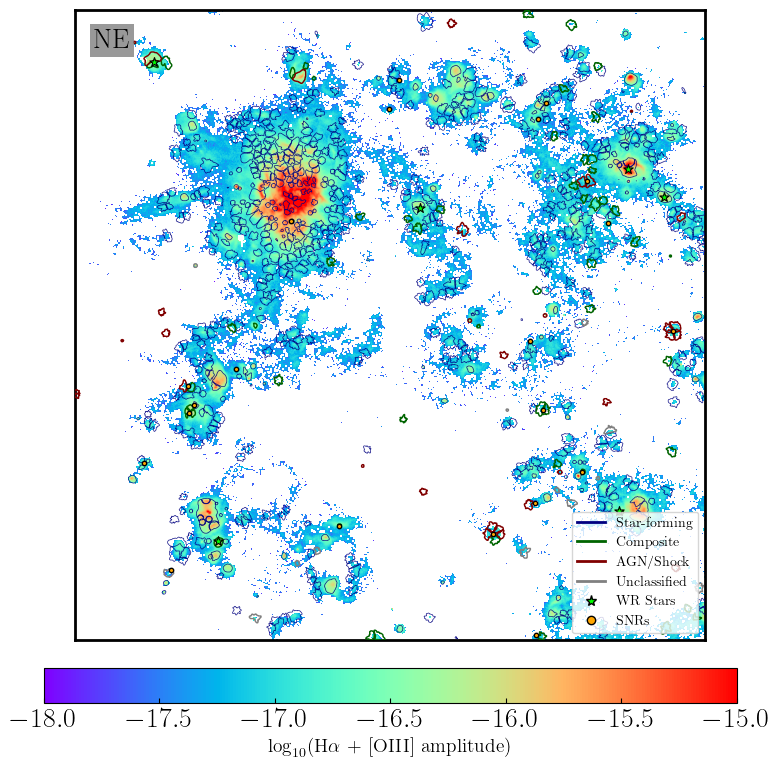

Plotting NW...


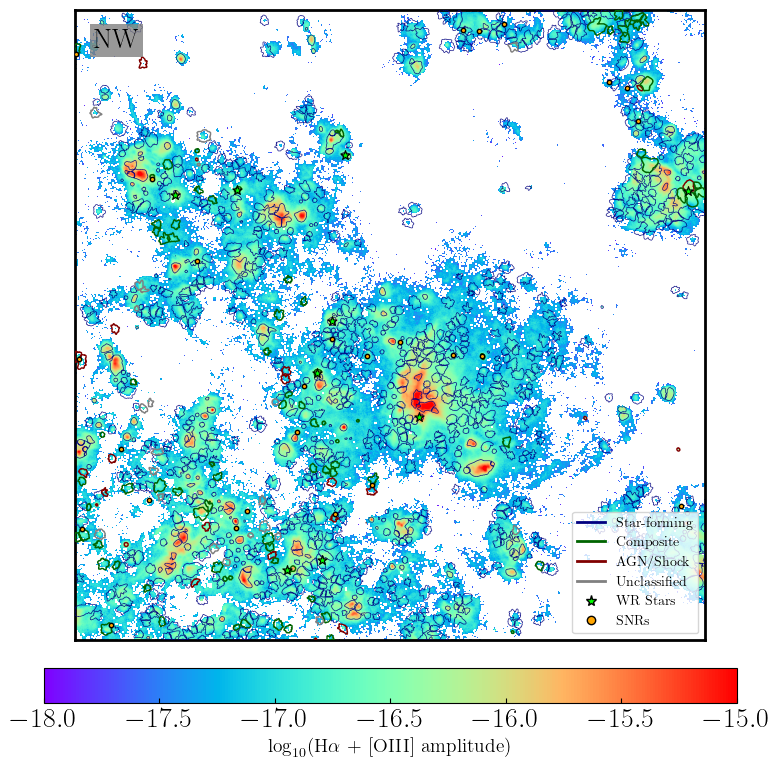

Plotting F5...


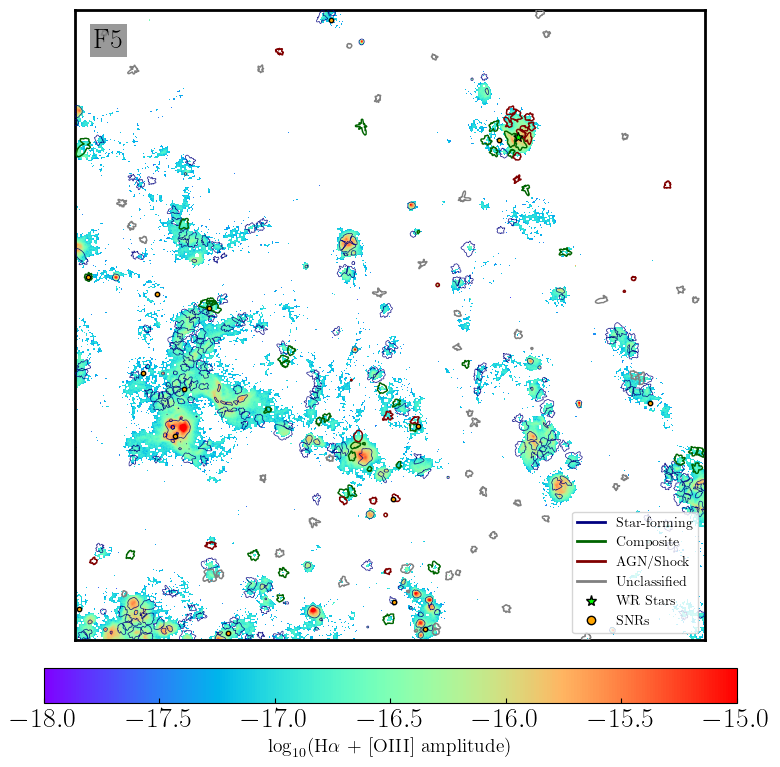

Plotting SE...


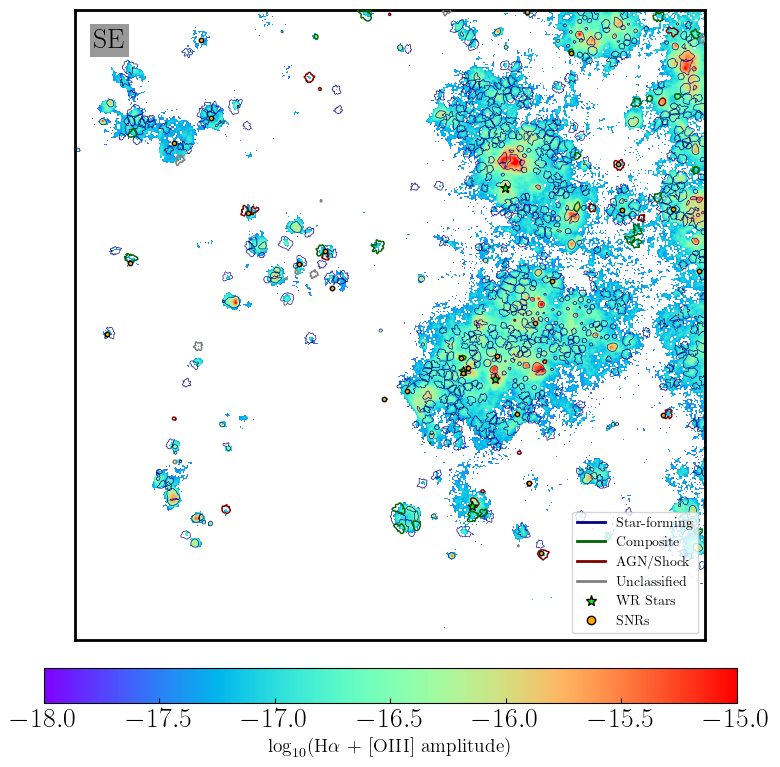

Plotting SW...


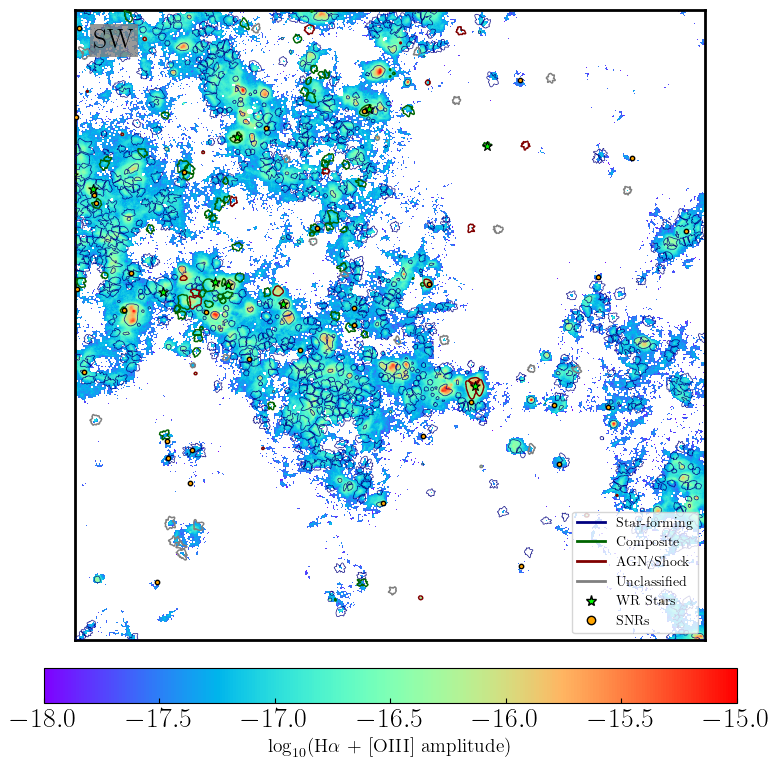

Plotting F7...


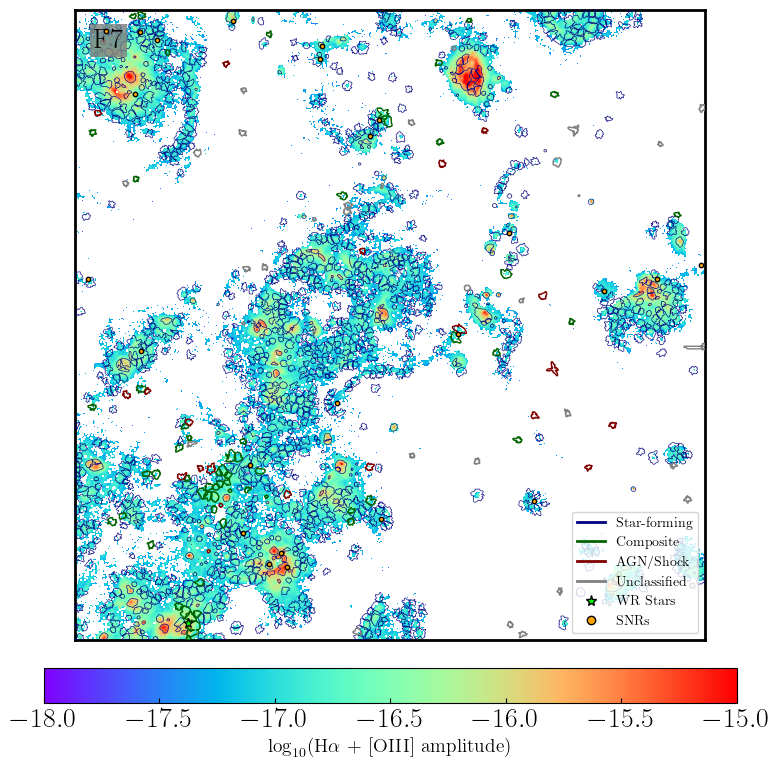

Plotting F6...


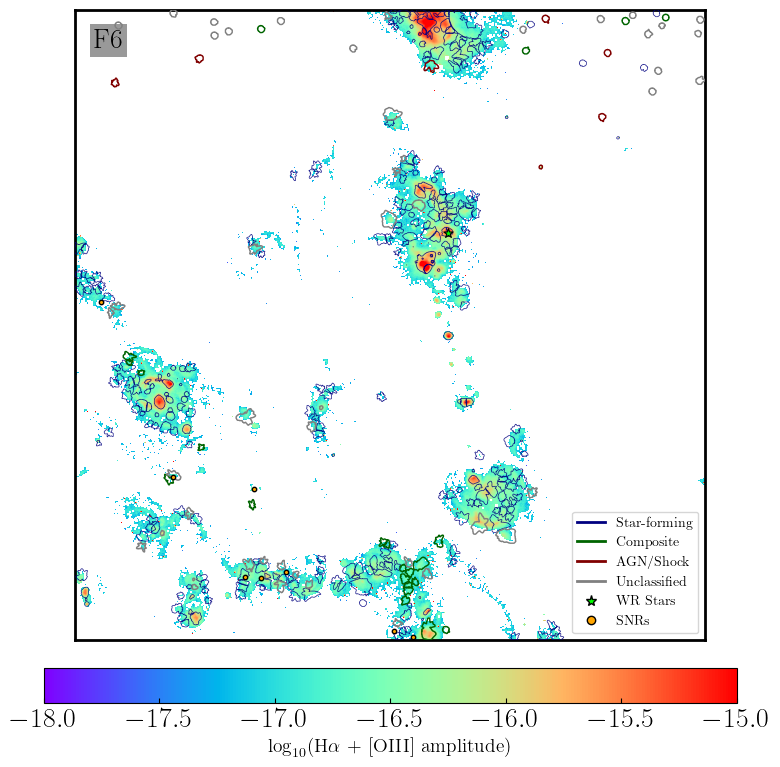

Plotting F8...


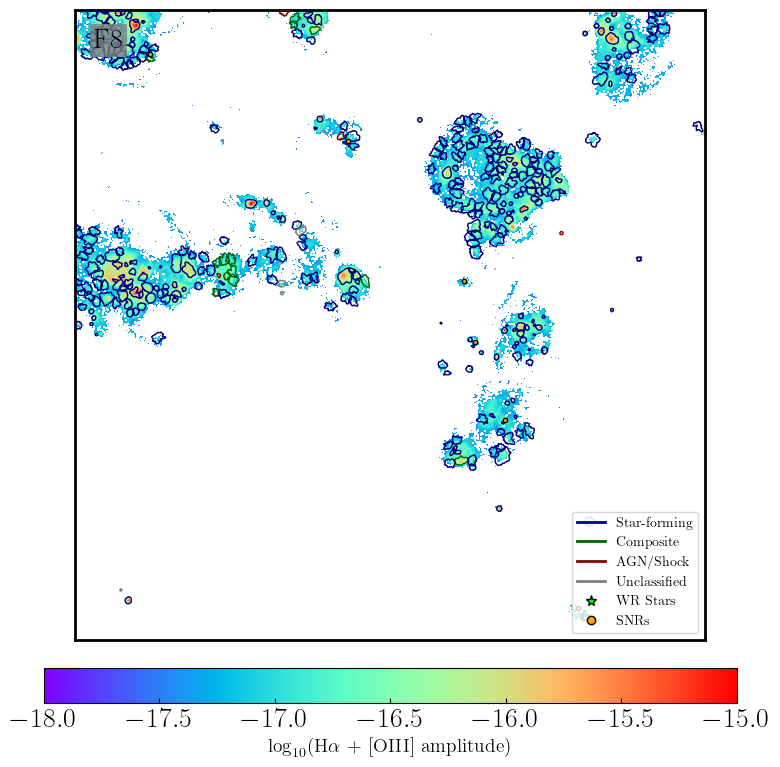

Plotting F9...


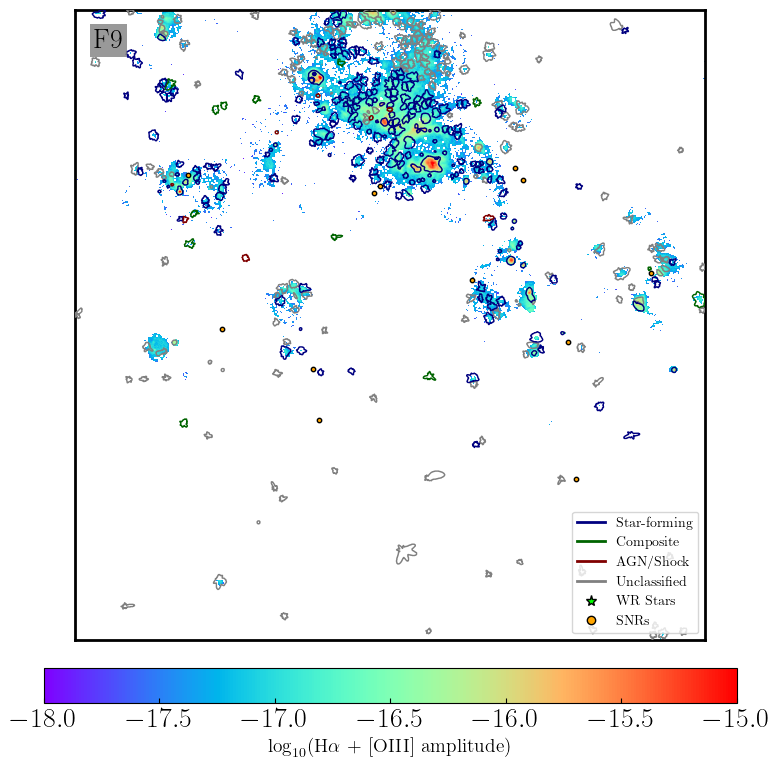

In [198]:
plot_all_m33_fields_separately(
    field_order=("NE", "NW", "F5", "SE", "SW", "F7", "F6", "F8", "F9"),
    output_dir="plots/individual_fields",
    ha_dir="../M33-Maps",
    ha_filename_pattern="M33-{FIELD}/M33-{FIELD}_SN3.LineMaps.map.Ha+OIII.1x1.amplitude.fits",
    catalog_dir="CATALOGS",
    catalog_pattern="flux_catalogs/flux_catalog_{FIELD}.csv",
    boundary_dir="Boundary_maps/Boundary_map_100pc",
    boundary_pattern="Boundary_map_{FIELD}.fits",   # use the true label map
    wcs_pattern="M33-{FIELD}/M33{FIELD}-Haflux.fits",
    xlim=(50, 2000),
    ylim=(50, 2000),
    cmap=cm.get_cmap("rainbow").copy(),
    vmin=-18,
    vmax=-15.0,
    region_id_col="region_id",
    bpt_col="BPT_class_sum_dered",
    class_colors={
        "Star-forming": "navy",
        "Composite": "darkgreen",
        "AGN/Shock": "maroon",
        "Unclassified": "gray",
    },
    boundary_lw=0.5,
    boundary_alpha=0.9,
    figsize=(9, 9),
    filetype="pdf",
    
)

In [9]:
# for path in [
#     "Boundary_maps/Boundary_map_100pc/ContDomain_map_NE.fits",
#     "Boundary_maps/Boundary_map_100pc/Boundary_map_NE.fits"
# ]:
#     data = fits.getdata(path)
#     arr = np.nan_to_num(data, nan=0)
#     print(path)
#     print("dtype:", data.dtype)
#     print("min/max:", np.nanmin(data), np.nanmax(data))
#     print("unique:", np.unique(arr)[:20])
#     print()

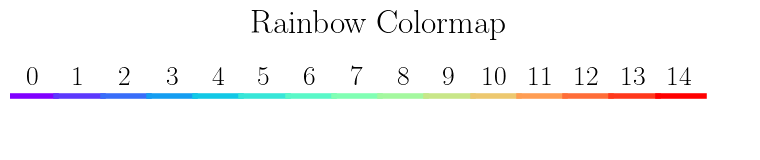

In [199]:
#draw 100 evenly spaced colours from the rainbow cmap
cmap = plt.get_cmap('rainbow')
colors = [cmap(i) for i in np.linspace(0, 1, 15)]
#show the colours
plt.figure(figsize=(8, 2))
for i, color in enumerate(colors):
    plt.plot([i, i + 1], [0, 0], color=color, lw=4)
#label each colour with its index
for i in range(len(colors)):
    plt.text(i + 0.5, 0.1, str(i), ha='center', va='bottom')
plt.xlim(0, len(colors) + 1)
plt.ylim(-1, 1)
plt.axis('off')
plt.title('Rainbow Colormap')
plt.tight_layout()

In [216]:
def plot_bpt(df,
             x_col='log_NII_Ha_sum_dered',
             x_col_err='log_NII_Ha_sum_dered_err',
             y_col='log_OIII_Hb_sum_dered',
             y_col2 = 'log_SII_Ha_sum_dered',
             class_col='BPT_class_sum_dered',
             snr_cut=3.0,
             figsize=(14, 6),
             savepath=None,
             color_col=None,                 # e.g. 'surface_brightness', 'Rgal', etc.
             marker_size=30,
             cmap='viridis',                 # colormap name or Colormap
             vmin=None, vmax=None,           # color scaling; None => inferred from data
             colorbar=True,
             colorbar_label=None,
             colorbar_log=False,             # True => log-normalize color scale
             missing_color='lightgray'        # used if some points have NaN color_col
            ):
    """
    Plot BPT diagrams:
      LEFT:  [NII]/Ha vs [OIII]/Hb
      RIGHT: [SII]/Ha vs [OIII]/Hb

    Classification is shown via marker shape (and legend).
    If color_col is provided, point facecolor is mapped to that column (with optional colorbar).
    """

    df = df.copy()

    # ---------------------------------------------------
    # Apply SNR cut
    # ---------------------------------------------------
    snr_cols = [f'SNR_{line}_sum' for line in ['Halpha', 'Hbeta', '[NII]6583', '[OIII]5007', '[SII]6731']]
    if all(col in df.columns for col in snr_cols):
        mask = np.ones(len(df), dtype=bool)
        for col in snr_cols:
            mask &= df[col] >= snr_cut
        df = df[mask]
    else:
        print("Warning: SNR columns not found; skipping SNR cut.")

    default_cmap = plt.cm.magma
    class_colors = {
        'Star-forming': colors[2],
        'Composite': colors[10],
        'AGN/Shock': colors[14],
        # 'Unclassified': 'grey',
    }

    shapes = {
        'Star-forming': 'o',
        'Composite': '^',
        'AGN/Shock': 's',
        # 'Unclassified': 'x',
    }

    # ---------------------------------------------------
    # Color mapping setup (if requested)
    # ---------------------------------------------------
    use_third_color = (color_col is not None) and (color_col in df.columns)
    print(f"Using third color: {use_third_color}" )
    norm = None
    sm = None
    if use_third_color:
        cvals_all = df[color_col].to_numpy()
        finite = np.isfinite(cvals_all)

        if vmin is None:
            vmin = np.nanmin(cvals_all[finite]) if np.any(finite) else 0.0
        if vmax is None:
            vmax = np.nanmax(cvals_all[finite]) if np.any(finite) else 1.0

        if colorbar_log:
            # avoid <=0 for LogNorm
            good = cvals_all[finite]
            good = good[good > 0]
            if good.size == 0:
                raise ValueError(f"colorbar_log=True but {color_col} has no positive finite values.")
            if vmin <= 0:
                vmin = np.nanmin(good)
            norm = mpl.colors.LogNorm(vmin=vmin, vmax=vmax)
        else:
            norm = mpl.colors.Normalize(vmin=vmin, vmax=vmax)

        cmap_obj = mpl.colormaps.get_cmap(cmap) if isinstance(cmap, str) else cmap
        sm = mpl.cm.ScalarMappable(norm=norm, cmap=cmap_obj)

    # ---------------------------------------------------
    # Figure setup
    # ---------------------------------------------------
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=figsize)

    # ---------------------------------------------------
    # LEFT: [NII]/Ha BPT
    # ---------------------------------------------------
    x_vals = np.linspace(-2, 1.0, 400)
    kewley_y = 0.61 / (x_vals - 0.47) + 1.19
    kauff_y  = 0.61 / (x_vals - 0.05) + 1.3

    for cls in shapes.keys():
        subset = df[df[class_col] == cls]
        if len(subset) == 0:
            continue

        # errorbars in gray (no markers)
        ax1.errorbar(subset['log_NII_Ha_sum_dered'], subset['log_OIII_Hb_sum_dered'],
                     xerr=subset['log_NII_Ha_err_sum_dered'],
                     yerr=subset['log_OIII_Hb_err_sum_dered'],
                     fmt='none', ecolor='lightgray',
                     elinewidth=0.8, capsize=1.5, zorder=1)

        # markers: either class color OR third-parameter color
        if use_third_color:
            cvals = subset[color_col].to_numpy()
            ok = np.isfinite(cvals)
            # valid colored points
            ax1.scatter(subset.loc[ok, 'log_NII_Ha_sum_dered'], subset.loc[ok, 'log_OIII_Hb_sum_dered'],
                        c=cvals[ok], cmap=sm.cmap, norm=sm.norm,
                        marker=shapes[cls], s=marker_size,
                        edgecolors='none', zorder=2)
            # missing colored points
            if np.any(~ok):
                ax1.scatter(subset.loc[~ok, 'log_NII_Ha_sum_dered'], subset.loc[~ok, 'log_OIII_Hb_sum_dered'],
                            c=missing_color, marker=shapes[cls], s=marker_size,
                            edgecolors='none', zorder=2, label=None)
        else:
            ax1.scatter(subset['log_NII_Ha_sum_dered'], subset['log_OIII_Hb_sum_dered'],
                        c=class_colors.get(cls, 'k'),
                        marker=shapes[cls], s=marker_size,
                        edgecolors='none', zorder=2)

    ax1.plot(x_vals, kauff_y, 'k--', lw=1.5, label='Kauffmann+03')
    ax1.plot(x_vals, kewley_y, 'k-',  lw=1.5, label='Kewley+01')

    ax1.set_xlim(-1.75, 0)
    ax1.set_ylim(-1.5, 1.5)
    ax1.set_xlabel(r'$\log([\mathrm{N\,II}]/\mathrm{H}\alpha)$')
    ax1.set_ylabel(r'$\log([\mathrm{O\,III}]/\mathrm{H}\beta)$')
    ax1.legend(frameon=False, loc='lower left', fontsize=15)

    # ---------------------------------------------------
    # RIGHT: [SII]/Ha BPT
    # ---------------------------------------------------
    x_vals_sii = np.linspace(-2, 0.5, 400)
    kewley_sii = 0.72 / (x_vals_sii - 0.32) + 1.30

    for cls in shapes.keys():
        subset = df[df[class_col] == cls]
        if len(subset) == 0:
            continue

        ax2.errorbar(subset['log_SII_Ha_sum_dered'], subset['log_OIII_Hb_sum_dered'],
                     xerr=subset['log_SII_Ha_err_sum_dered'],
                     yerr=subset['log_OIII_Hb_err_sum_dered'],
                     fmt='none', ecolor='lightgray',
                     elinewidth=0.8, capsize=1.5, zorder=1)

        if use_third_color:
            cvals = subset[color_col].to_numpy()
            ok = np.isfinite(cvals)
            ax2.scatter(subset.loc[ok, 'log_SII_Ha_sum_dered'], subset.loc[ok, 'log_OIII_Hb_sum_dered'],
                        c=cvals[ok], cmap=sm.cmap, norm=sm.norm,
                        marker=shapes[cls], s=marker_size, 
                        edgecolors='none', zorder=2)
            if np.any(~ok):
                ax2.scatter(subset.loc[~ok, 'log_SII_Ha_sum_dered'], subset.loc[~ok, 'log_OIII_Hb_sum_dered'],
                            c=missing_color, marker=shapes[cls], s=marker_size,
                            edgecolors='none', zorder=2)
        else:
            ax2.scatter(subset['log_SII_Ha_sum_dered'], subset['log_OIII_Hb_sum_dered'],
                        c=class_colors.get(cls, 'k'),
                        marker=shapes[cls], s=marker_size,
                        edgecolors='none', zorder=2)

    ax2.plot(x_vals_sii, kewley_sii, 'k-', lw=1.5, label='Kewley+01')

    ax2.set_xlim(-1.75, 0.3)
    ax2.set_ylim(-1.5, 1.5)
    ax2.set_xlabel(r'$\log([\mathrm{S\,II}]/\mathrm{H}\alpha)$')
    ax2.set_ylabel(r'$\log([\mathrm{O\,III}]/\mathrm{H}\beta)$')

    # ticks/spines styling
    ax1.minorticks_on()
    ax2.minorticks_on()
    ax2.tick_params(direction='in', which='both')
    ax1.tick_params(direction='in', which='both')

    for spine in ax1.spines.values():
        spine.set_visible(True)
        spine.set_linewidth(2.0)
        spine.set_edgecolor("black")
    for spine in ax2.spines.values():
        spine.set_visible(True)
        spine.set_linewidth(2.0)
        spine.set_edgecolor("black")

    # ---------------------------------------------------
    # Shared colorbar (if requested)
    # ---------------------------------------------------
    if use_third_color and colorbar and sm is not None:
        cax = fig.add_axes([1, 0.16, 0.02, 0.78]) # [left, bottom, width, height]
        cbar = fig.colorbar(sm, cax=cax)

        if colorbar_label is None:
            colorbar_label = color_col
        cbar.set_label(colorbar_label)

    plt.tight_layout()

    if savepath:
        plt.savefig(savepath, dpi=300, bbox_inches='tight')

    plt.show()
    return fig, (ax1, ax2)


Using third color: True


/var/folders/90/nb83zn5j00bc53x6bcv0jcwm0000gn/T/ipykernel_40651/1193210986.py:208: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


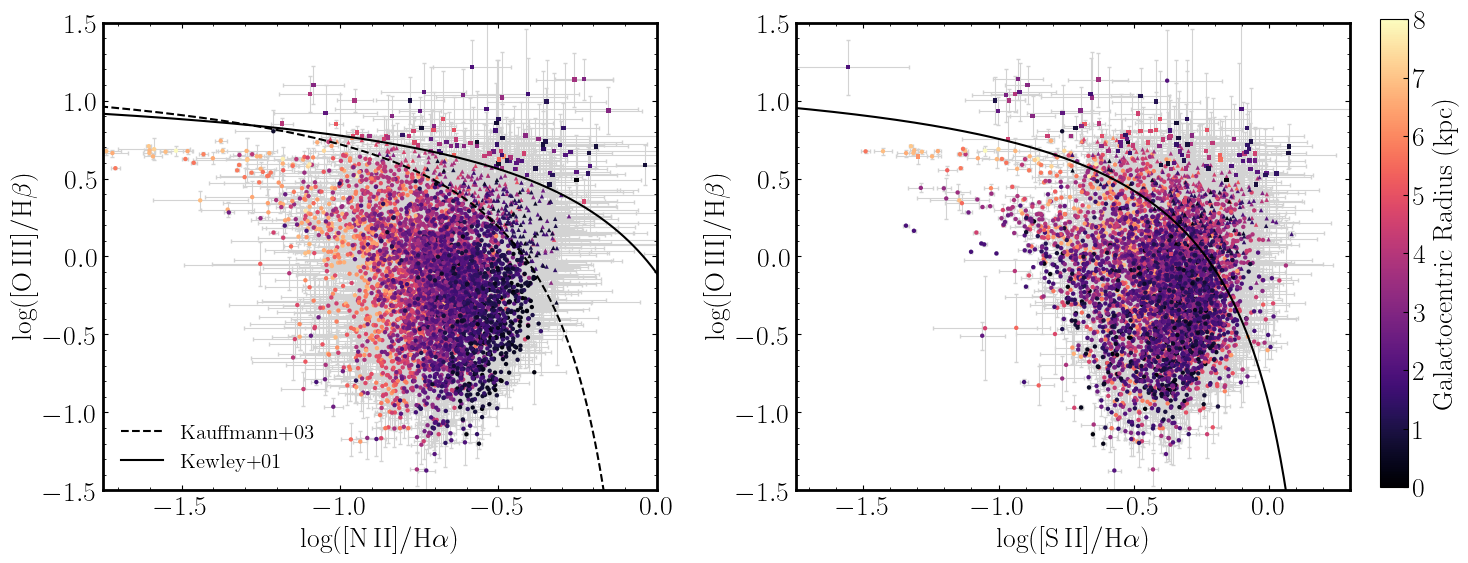

Using third color: False


/var/folders/90/nb83zn5j00bc53x6bcv0jcwm0000gn/T/ipykernel_40651/1193210986.py:127: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ax1.scatter(subset['log_NII_Ha_sum_dered'], subset['log_OIII_Hb_sum_dered'],
/var/folders/90/nb83zn5j00bc53x6bcv0jcwm0000gn/T/ipykernel_40651/1193210986.py:170: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ax2.scatter(subset['log_SII_Ha_sum_dered'], subset['log_OIII_Hb_sum_dered'],


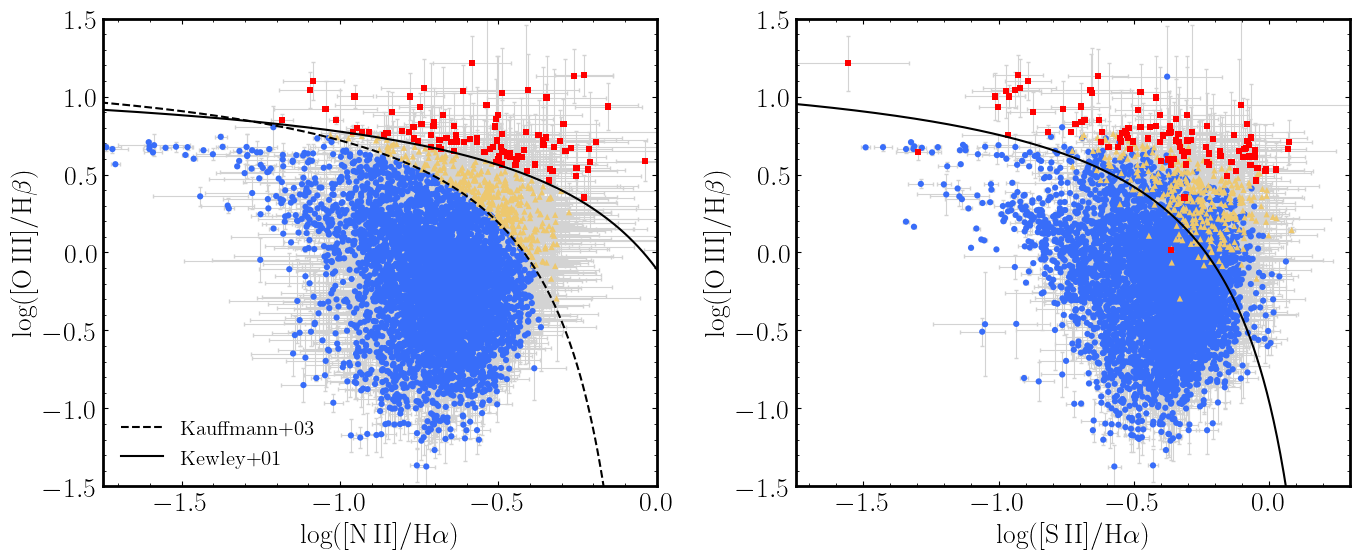

(<Figure size 1400x600 with 2 Axes>,
 (<Axes: xlabel='$\\log([\\mathrm{N\\,II}]/\\mathrm{H}\\alpha)$', ylabel='$\\log([\\mathrm{O\\,III}]/\\mathrm{H}\\beta)$'>,
  <Axes: xlabel='$\\log([\\mathrm{S\\,II}]/\\mathrm{H}\\alpha)$', ylabel='$\\log([\\mathrm{O\\,III}]/\\mathrm{H}\\beta)$'>))

In [217]:
snr_cut=3
plot_bpt(cat, snr_cut=snr_cut, marker_size = 10, color_col = 'R_gal_kpc', cmap='magma', vmin=0, vmax=8, colorbar_label='Galactocentric Radius (kpc)',
         savepath = f'plots/M33_allfields_BPT_SNR{snr_cut}_colored_by_radius.png')


plot_bpt(cat, snr_cut=snr_cut, marker_size = 20, 
         savepath = f'plots/M33_allfields_BPT_SNR{snr_cut}.png')

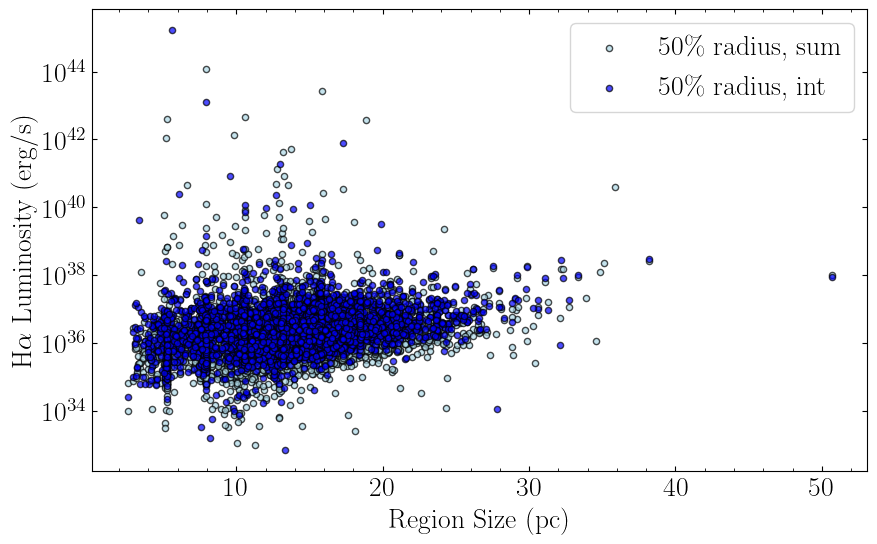

In [202]:
# plot radius vs luminosity
#don't include regions with tiny radius
mask = (cat['radius_p16_pc'] > 1) & (cat['radius_p50_pc'] > 1) & (cat['radius_p84_pc'] > 1)

plt.figure(figsize=(10, 6))
# plt.scatter(cat['radius_p84_pc'][mask], cat['L_Ha_sum_dered'][mask], s=20, alpha=0.7, edgecolor='k', color = 'hotpink', label = r'84\% radius')
plt.scatter(cat['radius_p50_pc'][mask], cat['L_Ha_sum_dered'][mask], s=20, alpha=0.7, edgecolor='k', color = 'lightblue', label = r'50\% radius, sum')
plt.scatter(cat['radius_p50_pc'][mask], cat['L_Ha_int_dered'][mask], s=20, alpha=0.7, edgecolor='k', color = 'blue', label = r'50\% radius, int')

# plt.scatter(cat['radius_p16_pc'][mask], cat['L_Ha_sum_dered'][mask], s=20, alpha=0.7, edgecolor='k', color = 'lightgreen', label = r'16\% radius')
plt.yscale('log')
plt.xlabel('Region Size (pc)')
plt.ylabel(r'H$\alpha$ Luminosity (erg/s)')
plt.minorticks_on()
plt.legend()
plt.savefig('plots/M33_HII_luminosity_vs_radius.png', dpi=300, bbox_inches='tight')
plt.show()

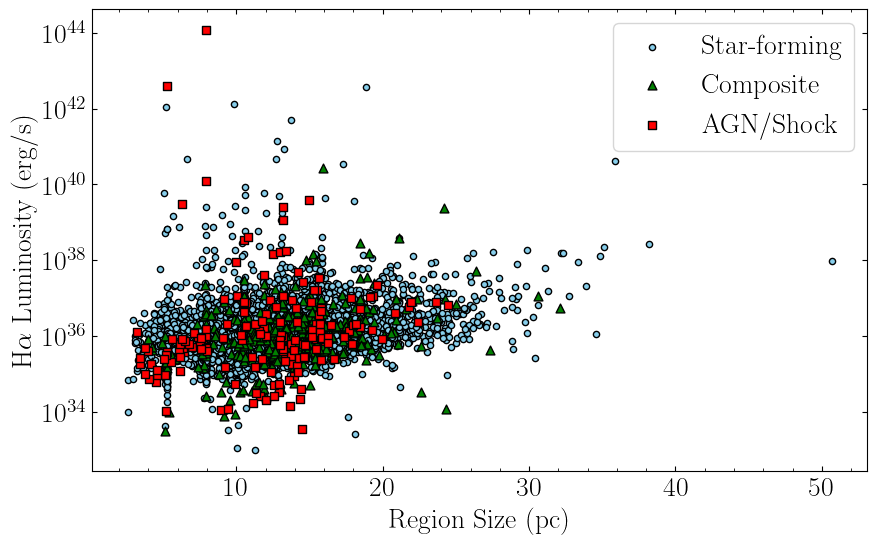

In [169]:
# plot radius vs luminosity
#don't include regions with tiny radius
mask = (cat['radius_p16_pc'] > 1) & (cat['radius_p50_pc'] > 1) & (cat['radius_p84_pc'] > 1)

plt.figure(figsize=(10, 6))
# plt.scatter(cat['radius_p84_pc'][mask], cat['L_Ha_sum_dered'][mask], s=20, alpha=0.7, edgecolor='k', color = 'purple', label = r'84\% radius')

plt.scatter(cat['radius_p50_pc'][mask & (cat['BPT_class_sum_dered'] == 'Star-forming')], 
            cat['L_Ha_sum_dered'][mask & (cat['BPT_class_sum_dered'] == 'Star-forming')], 
            s=20, alpha=1, edgecolor='k', color = 'skyblue', marker='o', label='Star-forming')

plt.scatter(cat['radius_p50_pc'][mask & (cat['BPT_class_sum_dered'] == 'Composite')], 
            cat['L_Ha_sum_dered'][mask & (cat['BPT_class_sum_dered'] == 'Composite')], 
            s=40, alpha=1, edgecolor='k', color = 'green', marker='^', label='Composite')

plt.scatter(cat['radius_p50_pc'][mask & (cat['BPT_class_sum_dered'] == 'AGN/Shock')], 
            cat['L_Ha_sum_dered'][mask & (cat['BPT_class_sum_dered'] == 'AGN/Shock')], 
            s=40, alpha=1, edgecolor='k', color = 'red', marker='s', label='AGN/Shock')

# plt.scatter(cat['radius_p16_pc'][mask], cat['L_Ha_sum_dered'][mask], s=20, alpha=0.7, edgecolor='k', color = 'hotpink', label = r'16\% radius')
plt.yscale('log')
plt.xlabel('Region Size (pc)')
plt.ylabel(r'H$\alpha$ Luminosity (erg/s)')
plt.minorticks_on()
plt.legend()
plt.savefig('plots/M33_HII_luminosity_vs_radius_BPT.png', dpi=300, bbox_inches='tight')
plt.show()

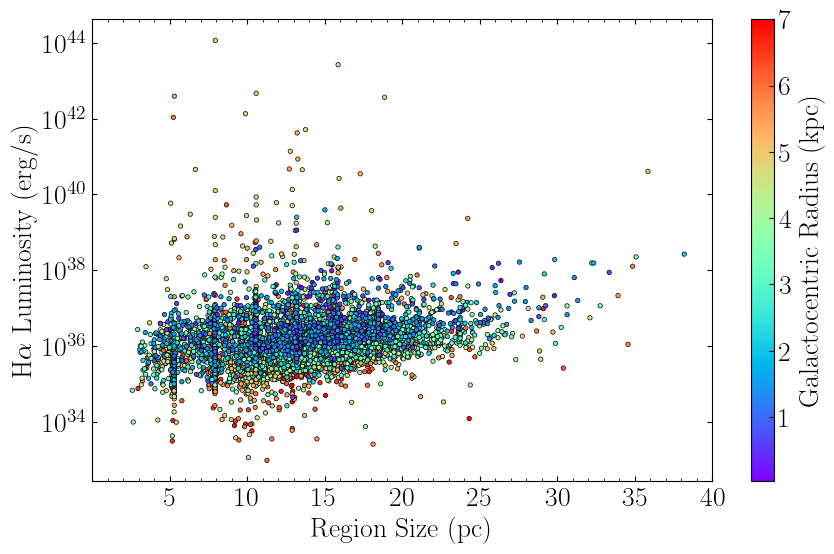

In [189]:
mask = (cat['radius_p16_pc'] > 1) & (cat['radius_p50_pc'] > 1) & (cat['radius_p84_pc'] > 1)

plt.figure(figsize=(10, 6))
plt.scatter(cat['radius_p50_pc'][mask], 
            cat['L_Ha_sum_dered'][mask], 
            s=10, alpha=1, c = cat['R_gal_kpc'][mask], vmax = 7, cmap = 'rainbow', edgecolor='k', linewidths=0.5,
            marker='o')
plt.yscale('log')
# plt.xscale('log')

#add x ticks at 10, 100, 1000
plt.xticks([5, 10, 15, 20, 25, 30, 35, 40, 45, 50], ['5', '10', '15', '20', '25', '30', '35', '40', '45', '50'])

plt.xlabel('Region Size (pc)')
plt.ylabel(r'H$\alpha$ Luminosity (erg/s)')
plt.minorticks_on()
plt.xlim(0,40)
# plt.legend()
plt.colorbar(label='Galactocentric Radius (kpc)')
plt.savefig('plots/M33_HII_luminosity_vs_radius_Rgal.png', dpi=300, bbox_inches='tight')
plt.show()

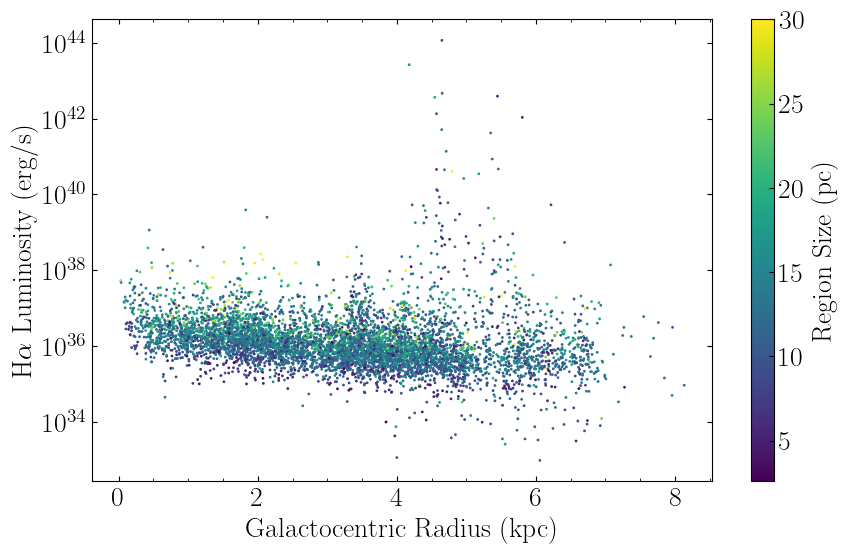

In [173]:
#plot luminosity vs galactocentric radius
plt.figure(figsize=(10, 6))
plt.scatter(cat['R_gal_kpc'][mask], 
            cat['L_Ha_sum_dered'][mask], 
            s=1, alpha=1, c = cat['radius_p50_pc'][mask], vmax = 30, marker='o')
plt.yscale('log')
plt.xlabel('Galactocentric Radius (kpc)')
plt.ylabel(r'H$\alpha$ Luminosity (erg/s)')
plt.minorticks_on()
plt.colorbar(label='Region Size (pc)')
plt.savefig('plots/M33_HII_luminosity_vs_Rgal.png', dpi=300, bbox_inches='tight')
plt.show()

In [219]:
for col in cat.columns:
    print(col)

region_id
npix_region
npix_edge_ring
F_Halpha_sum
F_Halpha_e_sum
SNR_Halpha_sum
Halpha_b_edge
F_Hbeta_sum
F_Hbeta_e_sum
SNR_Hbeta_sum
Hbeta_b_edge
F_[OIII]5007_sum
F_[OIII]5007_e_sum
SNR_[OIII]5007_sum
[OIII]5007_b_edge
F_[SII]6716_sum
F_[SII]6716_e_sum
SNR_[SII]6716_sum
[SII]6716_b_edge
F_[SII]6731_sum
F_[SII]6731_e_sum
SNR_[SII]6731_sum
[SII]6731_b_edge
F_[NII]6583_sum
F_[NII]6583_e_sum
SNR_[NII]6583_sum
[NII]6583_b_edge
F_[OII]3727_sum
F_[OII]3727_e_sum
SNR_[OII]3727_sum
[OII]3727_b_edge
field
y
x
removed_by_saddle
removed_by_edge
kind
center_x_px
center_y_px
zoi_center_label
bg_local
sigma_local
radius_p16_px
radius_p50_px
radius_p84_px
radius_p16_pc
radius_p50_pc
radius_p84_pc
radius_areaeq_px
radius_areaeq_pc
boundary_method
area_px_after_carve
radius_areaeq_px_after_carve
radius_areaeq_pc_after_carve
id_int
x_int
y_int
FIELD_int
F_[OII]3727_int
F_[OII]3727_e_int
SNR_[OII]3727_int
F_Hbeta_int
F_Hbeta_e_int
SNR_Hbeta_int
F_[OIII]4959_int
F_[OIII]4959_e_int
SNR_[OIII]4959_int
F_[OI

In [252]:
# #plot Av vs galactocentric radius
# mask = np.isfinite(cat['sum_A_V']) & np.isfinite(cat['R_gal_kpc']) & (cat['sum_A_V'] > 0)  & (cat['sum_A_V'] < 3)

# plt.figure(figsize=(10, 6))
# plt.scatter(cat['R_gal_kpc'][mask], 
#             cat['sum_A_V'][mask],
#             s=10, alpha=0.1, c = colors[0], vmax = 30, marker='o',
#             )

# #bin the points and plot the median and +16/84 percentiles in each bin
# bins = np.arange(0, 20, 0.5)
# bin_centers = 0.5 * (bins[:-1] + bins[1:])
# medians = []
# upper_errs = []
# lower_errs = []
# stds = []  
# for i in range(len(bins) - 1):
#     in_bin = (cat['R_gal_kpc'] >= bins[i]) & (cat['R_gal_kpc'] < bins[i+1]) & mask
#     if np.sum(in_bin) > 0:
#         medians.append(np.median(cat['sum_A_V'][in_bin]))
#         lower_errs.append(np.percentile(cat['sum_A_V'][in_bin], 16))
#         upper_errs.append(np.percentile(cat['sum_A_V'][in_bin], 84))
#     else:
#         medians.append(np.nan)
#         lower_errs.append(np.nan)
#         upper_errs.append(np.nan)
        
# #convert to numpy arrays
# medians = np.array(medians)
# lower_errs = np.array(lower_errs)
# upper_errs = np.array(upper_errs)


# plt.errorbar(bin_centers, medians, yerr=[medians - lower_errs, upper_errs - medians], fmt='o', color='k', ecolor='k', 
#              elinewidth=1.5, capsize=3, label=r'Median $\pm1\sigma$ in bins')
# plt.xlabel('Galactocentric Radius (kpc)')
# plt.ylabel(r'Av (mag)')
# plt.minorticks_on()
# # plt.ylim(0, 3)
# plt.legend()
# plt.savefig('plots/M33_HII_Av_vs_Rgal.png', dpi=300, bbox_inches='tight')
# plt.show()


In [ ]:
def plot_radial_gradient(
    cat,
    xcol,
    ycol,
    mask=None,
    bins=None,
    color='C0',
    xlabel='Galactocentric Radius (kpc)',
    ylabel='Value',
    title=None,
    scatter_label=None,
    summary_label=r'Median $\pm 1\sigma$ in bins',
    xlim=None,
    ylim=None,
    yscale='linear',
    savepath=None,
    show=True,
    figsize=(10, 6),
    scatter_kwargs=None,
    errorbar_kwargs=None,
    alpha=0.5,
):
    """
    Plot a radial gradient for ycol vs xcol, including scatter points and
    binned median with 16th/84th percentile error bars.

    Parameters
    ----------
    cat : dict-like, pandas DataFrame, astropy Table, or structured array
        Catalog containing xcol and ycol.
    xcol : str
        Name of the radius column (x-axis).
    ycol : str
        Name of the quantity column (y-axis).
    mask : array-like of bool, optional
        Boolean mask selecting rows to plot. If None, uses finite values only.
    bins : array-like, optional
        Bin edges. Default is np.arange(0, 20, 0.5).
    color : str, optional
        Scatter color.
    xlabel, ylabel : str, optional
        Axis labels.
    title : str, optional
        Plot title.
    scatter_label : str, optional
        Label for scatter points.
    summary_label : str, optional
        Label for binned median/error bars.
    xlim, ylim : tuple, optional
        Axis limits.
    savepath : str, optional
        If given, save figure to this path.
    show : bool, optional
        Whether to display the plot.
    figsize : tuple, optional
        Figure size.
    scatter_kwargs : dict, optional
        Extra keyword args passed to plt.scatter.
    errorbar_kwargs : dict, optional
        Extra keyword args passed to plt.errorbar.

    Returns
    -------
    results : dict
        Dictionary with bin_centers, medians, lower_errs, upper_errs.
    """
    x = np.asarray(cat[xcol])
    y = np.asarray(cat[ycol])

    if mask is None:
        mask = np.isfinite(x) & np.isfinite(y)
    else:
        mask = np.asarray(mask) & np.isfinite(x) & np.isfinite(y)

    if bins is None:
        bins = np.arange(0, 20, 0.5)

    scatter_defaults = dict(s=10, alpha=alpha, c=color, marker='o')
    if scatter_kwargs is not None:
        scatter_defaults.update(scatter_kwargs)

    errorbar_defaults = dict(
        fmt='o',
        color='k',
        ecolor='k',
        elinewidth=1.5,
        capsize=3,
        label=summary_label,
    )
    if errorbar_kwargs is not None:
        errorbar_defaults.update(errorbar_kwargs)

    bin_centers = 0.5 * (bins[:-1] + bins[1:])
    medians = []
    lower_errs = []
    upper_errs = []
    counts = []

    for i in range(len(bins) - 1):
        in_bin = (x >= bins[i]) & (x < bins[i + 1]) & mask
        counts.append(np.sum(in_bin))

        if np.sum(in_bin) > 0:
            y_bin = y[in_bin]
            medians.append(np.median(y_bin))
            lower_errs.append(np.percentile(y_bin, 16))
            upper_errs.append(np.percentile(y_bin, 84))
        else:
            medians.append(np.nan)
            lower_errs.append(np.nan)
            upper_errs.append(np.nan)

    medians = np.array(medians)
    lower_errs = np.array(lower_errs)
    upper_errs = np.array(upper_errs)
    counts = np.array(counts)

    plt.figure(figsize=figsize)

    plt.scatter(x[mask], y[mask], label=scatter_label, **scatter_defaults)
    
    valid = np.isfinite(medians)
    plt.errorbar(
        bin_centers[valid],
        medians[valid],
        yerr=[
            medians[valid] - lower_errs[valid],
            upper_errs[valid] - medians[valid]
        ],
        **errorbar_defaults
    )

    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.minorticks_on()
    plt.yscale(yscale)
    if title is not None:
        plt.title(title)
    if xlim is not None:
        plt.xlim(*xlim)
    if ylim is not None:
        plt.ylim(*ylim)

    if scatter_label is not None or summary_label is not None:
        plt.legend()

    if savepath is not None:
        plt.savefig(savepath, dpi=300, bbox_inches='tight')

    if show:
        plt.show()
    else:
        plt.close()

    return {
        'bin_centers': bin_centers,
        'medians': medians,
        'lower_errs': lower_errs,
        'upper_errs': upper_errs,
        'counts': counts,
    }

/var/folders/90/nb83zn5j00bc53x6bcv0jcwm0000gn/T/ipykernel_40651/1335660125.py:123: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(x[mask], y[mask], label=scatter_label, **scatter_defaults)


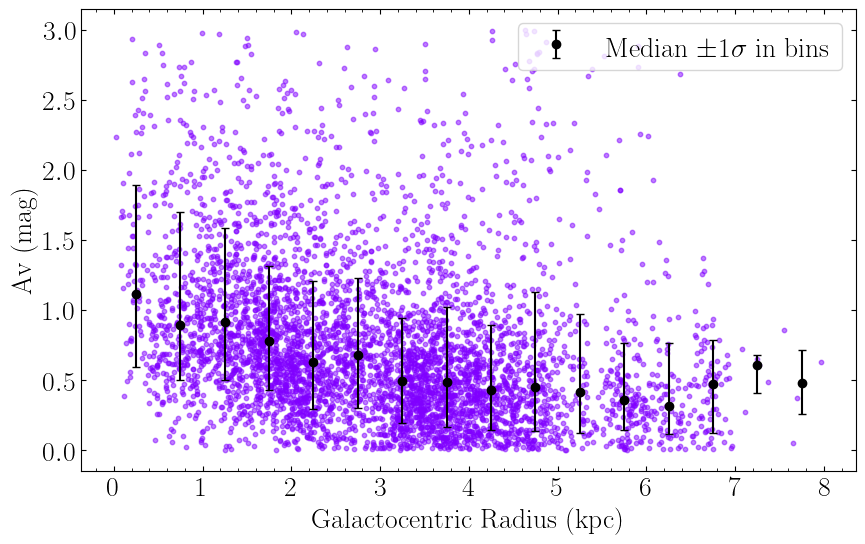

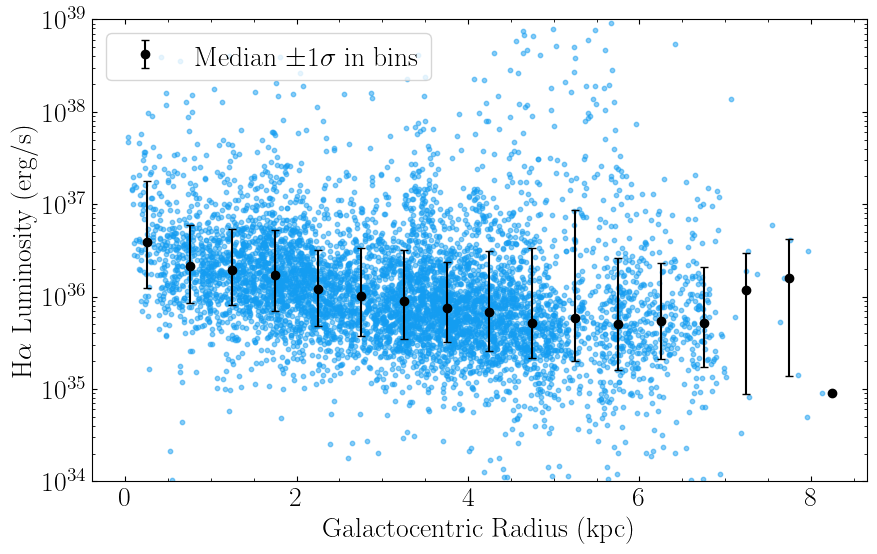

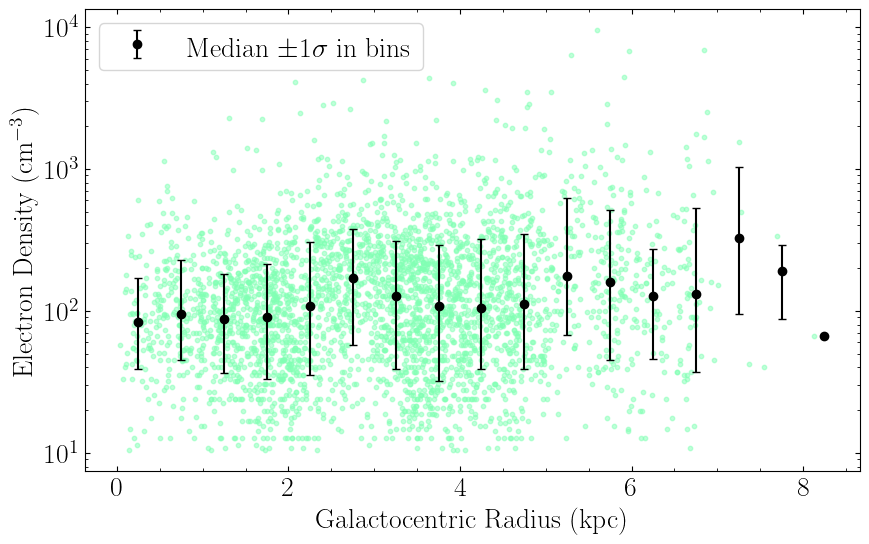

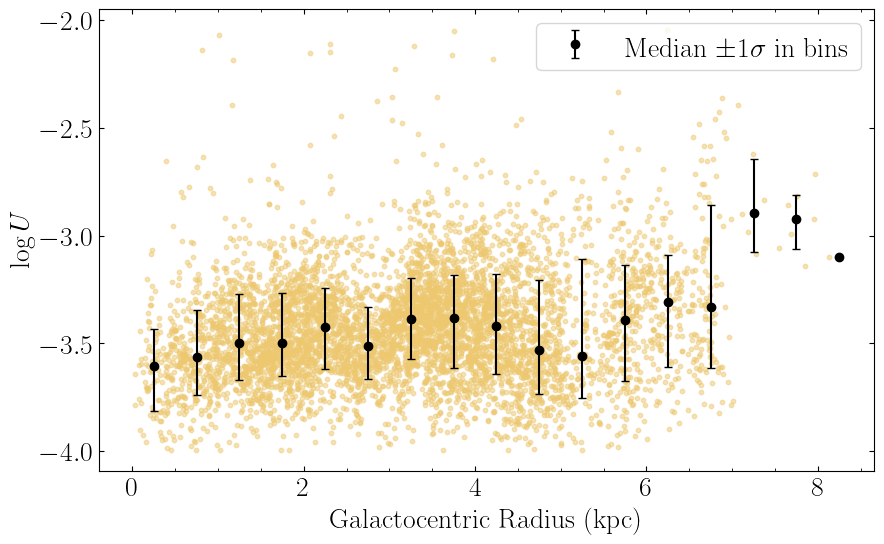

In [281]:
"""
AV
"""
mask = (
    np.isfinite(cat['sum_A_V']) &
    np.isfinite(cat['R_gal_kpc']) &
    (cat['sum_A_V'] > 0) &
    (cat['sum_A_V'] < 3)
)

results = plot_radial_gradient(
    cat=cat,
    xcol='R_gal_kpc',
    ycol='sum_A_V',
    mask=mask,
    bins=np.arange(0, 20, 0.5),
    color=colors[0],
    xlabel='Galactocentric Radius (kpc)',
    ylabel=r'Av (mag)',
    savepath='plots/M33_HII_Av_vs_Rgal.png'
)

"""
Ha Luminosity
"""
mask = (
    np.isfinite(cat['L_Ha_sum_dered']) &
    np.isfinite(cat['R_gal_kpc']) &
    (cat['L_Ha_sum_dered'] < 1e40) &
    (cat['L_Ha_sum_dered'] > 1e34)
)

results = plot_radial_gradient(
    cat=cat,
    xcol='R_gal_kpc',
    ycol='L_Ha_sum_dered',
    mask=mask,
    bins=np.arange(0, 20, 0.5),
    color=colors[3],
    xlabel='Galactocentric Radius (kpc)',
    ylabel=r'H$\alpha$ Luminosity (erg/s)',
    ylim=(1e34, 1e39),
    yscale='log',
    savepath='plots/M33_HII_L_Ha_sum_dered_vs_Rgal.png'
)
"""
ne
"""
mask = (
    np.isfinite(cat['ne_SII_cm3']) &
    np.isfinite(cat['R_gal_kpc']) &
    (cat['ne_SII_cm3'] < 10000) &
    (cat['ne_SII_cm3'] > 10)
)

results = plot_radial_gradient(
    cat=cat,
    xcol='R_gal_kpc',
    ycol='ne_SII_cm3',
    mask=mask,
    bins=np.arange(0, 20, 0.5),
    color=colors[7],
    xlabel='Galactocentric Radius (kpc)',
    ylabel=r'Electron Density (cm$^{-3}$)',
    # ylim=(0, 1000),
    yscale='log',
    alpha=0.5,
    savepath='plots/M33_HII_ne_SII_cm3_vs_Rgal.png'
)

"""
Ionization parameter
"""

mask = (
    np.isfinite(cat['logU_KK04']) &
    np.isfinite(cat['R_gal_kpc']) &
    (cat['logU_KK04'] < -2) &
    (cat['logU_KK04'] > -4)
)
results = plot_radial_gradient(
    cat=cat,
    xcol='R_gal_kpc',
    ycol='logU_KK04',
    mask=mask,
    bins=np.arange(0, 20, 0.5),
    color=colors[10],
    xlabel='Galactocentric Radius (kpc)',
    ylabel=r'$\log U$',
    # ylim=(-4, -2),
    yscale='linear',
    alpha=0.5,
    savepath='plots/M33_HII_log_U_KK04_vs_Rgal.png'
)

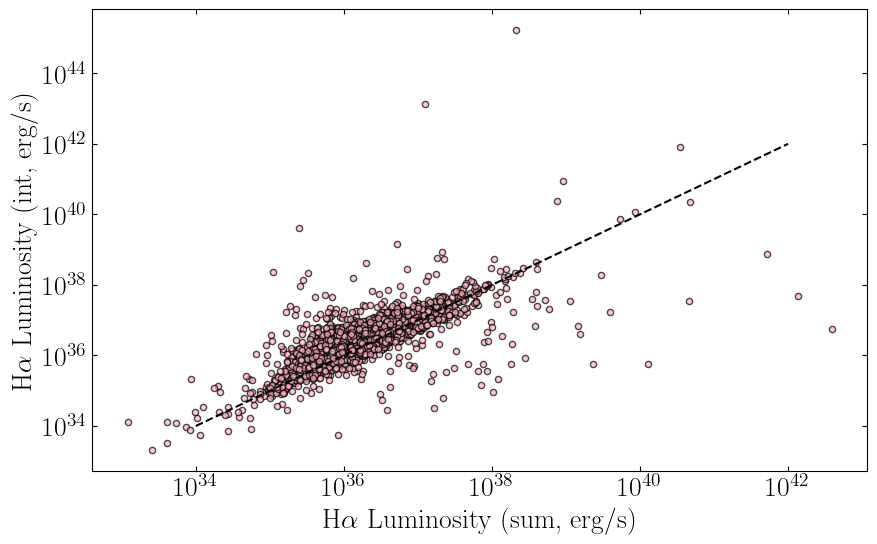

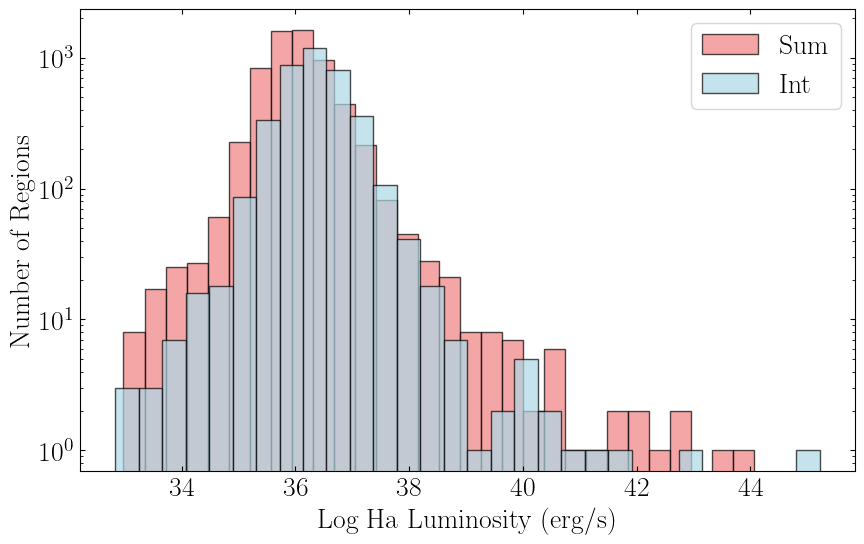

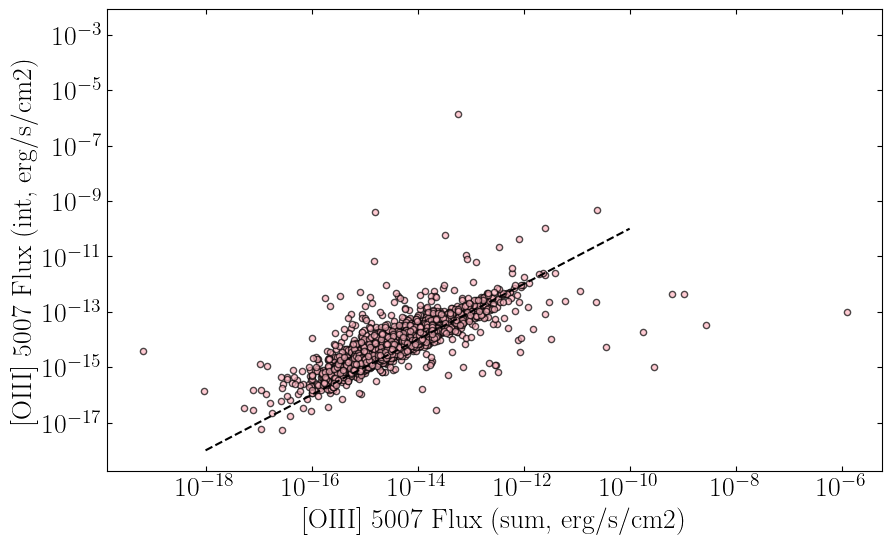

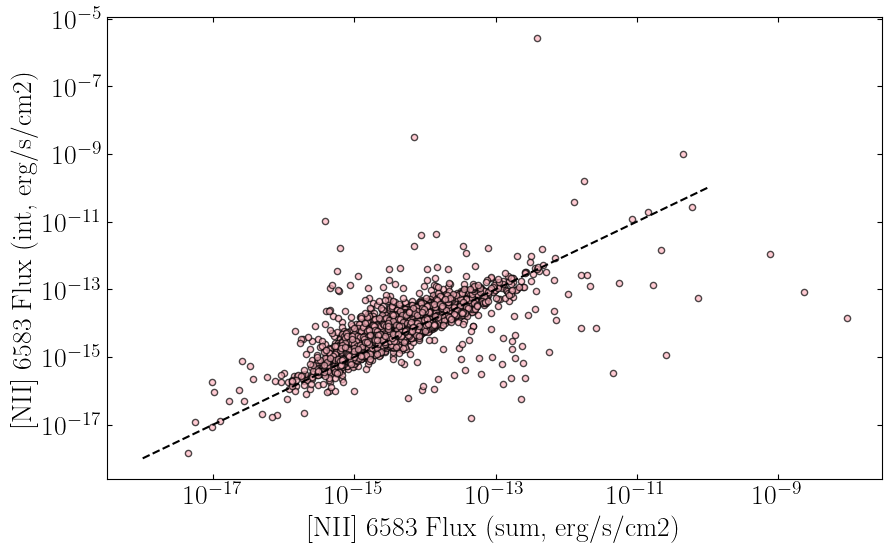

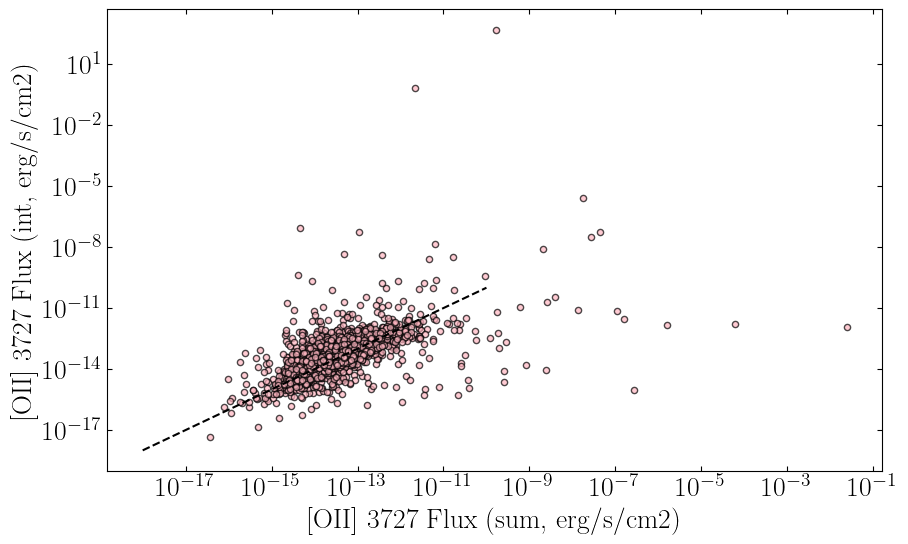

In [250]:
plt.figure(figsize=(10, 6))
plt.scatter(cat['L_Ha_sum_dered'], cat['L_Ha_int_dered'], s=20, alpha=0.7, edgecolor='k', color = 'lightpink')
plt.plot([1e34, 1e42], [1e34, 1e42], 'k--')
plt.xscale('log')
plt.yscale('log')
plt.xlabel(r'H$\alpha$ Luminosity (sum, erg/s)')
plt.ylabel(r'H$\alpha$ Luminosity (int, erg/s)')
plt.minorticks_on()
plt.show()

#also make a histogram of the luminosities
plt.figure(figsize=(10, 6))
plt.hist(np.log10(cat['L_Ha_sum_dered']), bins=30, color='lightcoral', edgecolor='k', alpha=0.7, label='Sum')
plt.hist(np.log10(cat['L_Ha_int_dered']), bins=30, color='lightblue', edgecolor='k', alpha=0.7, label='Int')
# plt.xscale('log')
plt.yscale('log')
plt.xlabel(r'Log Ha Luminosity (erg/s)')
plt.ylabel('Number of Regions')
plt.legend()
# plt.savefig('plots/M33_HII_luminosity_ratio_histogram.png', dpi=300, bbox_inches='tight')
plt.show()

#compare fluxes too

#OIII
plt.figure(figsize=(10, 6))
plt.scatter(cat['F_[OIII]5007_sum_dered'], cat['F_[OIII]5007_int_dered'], s=20, alpha=0.7, edgecolor='k', color = 'lightpink')
plt.plot([1e-18, 1e-10], [1e-18, 1e-10], 'k--')
plt.xscale('log')
plt.yscale('log')
plt.xlabel(r'[OIII] 5007 Flux (sum, erg/s/cm2)')
plt.ylabel(r'[OIII] 5007 Flux (int, erg/s/cm2)')
plt.minorticks_on()
plt.show()

#NII
plt.figure(figsize=(10, 6))
plt.scatter(cat['F_[NII]6583_sum_dered'], cat['F_[NII]6583_int_dered'], s=20, alpha=0.7, edgecolor='k', color = 'lightpink')
plt.plot([1e-18, 1e-10], [1e-18, 1e-10], 'k--')
plt.xscale('log')
plt.yscale('log')
plt.xlabel(r'[NII] 6583 Flux (sum, erg/s/cm2)')
plt.ylabel(r'[NII] 6583 Flux (int, erg/s/cm2)')
plt.minorticks_on()
plt.show()

#OII
plt.figure(figsize=(10, 6))
plt.scatter(cat['F_[OII]3727_sum_dered'], cat['F_[OII]3727_int_dered'], s=20, alpha=0.7, edgecolor='k', color = 'lightpink')
plt.plot([1e-18, 1e-10], [1e-18, 1e-10], 'k--') 
plt.xscale('log')
plt.yscale('log')
plt.xlabel(r'[OII] 3727 Flux (sum, erg/s/cm2)')
plt.ylabel(r'[OII] 3727 Flux (int, erg/s/cm2)')
plt.minorticks_on()
plt.show()

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


(0.0, 50.0)

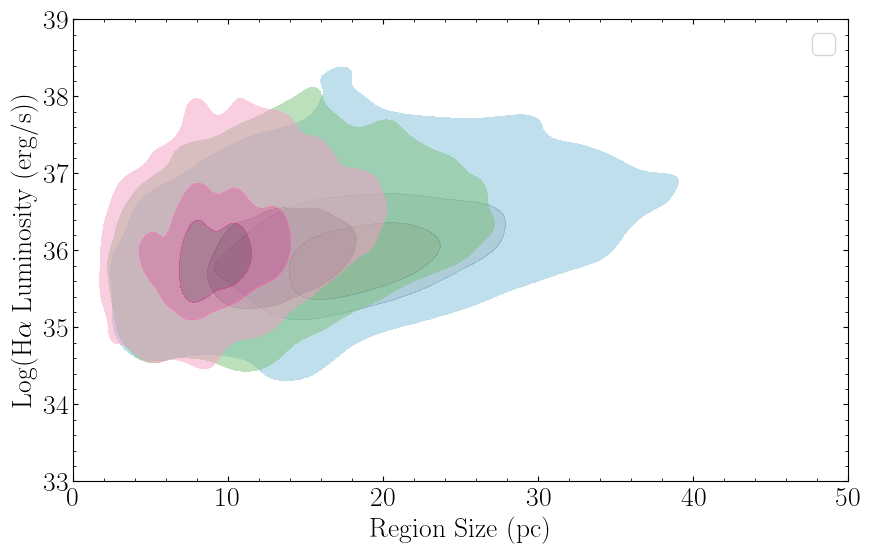

In [ ]:

#remove nans and infs, and also filter out tiny radii
mask = (cat['radius_p16_pc'] > 1) & (cat['radius_p50_pc'] > 1) & (cat['radius_p84_pc'] > 1)

plt.figure(figsize=(10,6))
# plt.scatter(cat['radius_p84_pc'][mask], np.log10(cat['L_Ha_sum_dered'][mask]), s=20, alpha=1,  color = 'hotpink', label = r'84\% radius')
# plt.scatter(cat['radius_p50_pc'][mask], np.log10(cat['L_Ha_sum_dered'][mask]), s=20, alpha=1, color = 'lightblue', label = r'50\% radius')
# plt.scatter(cat['radius_p16_pc'][mask], np.log10(cat['L_Ha_sum_dered'][mask]), s=20, alpha=1, color = 'lightgreen', label = r'16\% radius')

sns.kdeplot(
    x=cat['radius_p84_pc'][mask],
    y=np.log10(cat['L_Ha_sum_dered'][mask]),
    levels=4,
    color='skyblue',
    # linewidths=2,
    label=r'84% radius',
    fill=True,
    alpha=0.5,
    thresh=0.05,
)

sns.kdeplot(
    x=cat['radius_p50_pc'][mask],
    y=np.log10(cat['L_Ha_sum_dered'][mask]),
    levels=3,
    color='lightgreen',
    # linewidths=2,
    label=r'50% radius',
    fill=True,
    alpha=0.5,
    thresh=0.05,
)

sns.kdeplot(
    x=cat['radius_p16_pc'][mask],
    y=np.log10(cat['L_Ha_sum_dered'][mask]),
    levels=4,
    color='hotpink',
    # linewidths=0,
    label=r'16% radius',
    fill=True,
    alpha=0.5,
    thresh=0.05,
    
)

# plt.yscale('log')
plt.xlabel('Region Size (pc)')
plt.ylabel(r'Log(H$\alpha$ Luminosity (erg/s))')
plt.minorticks_on()
#add legend for sns plot
plt.legend()
plt.ylim(33,39)
plt.xlim(0, 50)

# plt.savefig('plots/M33_HII_luminosity_vs_radius_contour.png',
#             dpi=300, bbox_inches='tight')
# plt.show()

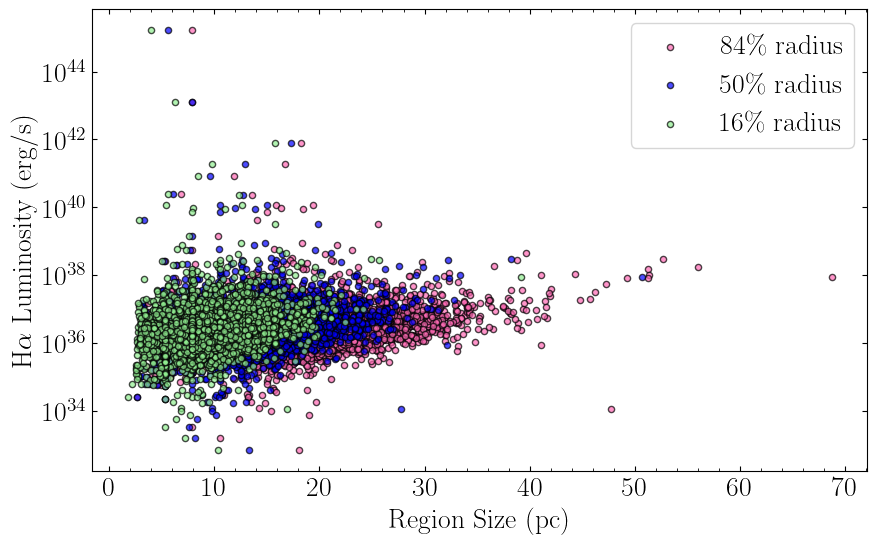

In [102]:
# plot radius vs luminosity
#don't include regions with tiny radius
mask = (cat['radius_p16_pc'] > 1) & (cat['radius_p50_pc'] > 1) & (cat['radius_p84_pc'] > 1)

plt.figure(figsize=(10, 6))
plt.scatter(cat['radius_p84_pc'][mask], cat['L_Ha_int_dered'][mask], s=20, alpha=0.7, edgecolor='k', color = 'hotpink', label = r'84\% radius')
plt.scatter(cat['radius_p50_pc'][mask], cat['L_Ha_int_dered'][mask], s=20, alpha=0.7, edgecolor='k', color = 'blue', label = r'50\% radius')
plt.scatter(cat['radius_p16_pc'][mask], cat['L_Ha_int_dered'][mask], s=20, alpha=0.7, edgecolor='k', color = 'lightgreen', label = r'16\% radius')
plt.yscale('log')
plt.xlabel('Region Size (pc)')
plt.ylabel(r'H$\alpha$ Luminosity (erg/s)')
plt.minorticks_on()
plt.legend()
plt.savefig('plots/M33_HII_luminosity_vs_radius.png', dpi=300, bbox_inches='tight')
plt.show()

In [47]:
# Print the range in value of each radius metric, exclusing values <= 1 pc
print(f"Radius p16 range: {cat['radius_p16_pc'][cat['radius_p16_pc'] > 1].min():.2f} - {cat['radius_p16_pc'][cat['radius_p16_pc'] > 1].max():.2f} pc")
print(f"Radius p50 range: {cat['radius_p50_pc'][cat['radius_p50_pc'] > 1].min():.2f} - {cat['radius_p50_pc'][cat['radius_p50_pc'] > 1].max():.2f} pc")
print(f"Radius p84 range: {cat['radius_p84_pc'][cat['radius_p84_pc'] > 1].min():.2f} - {cat['radius_p84_pc'][cat['radius_p84_pc'] > 1].max():.2f} pc")

Radius p16 range: 1.25 - 39.14 pc
Radius p50 range: 1.60 - 50.70 pc
Radius p84 range: 2.58 - 68.77 pc


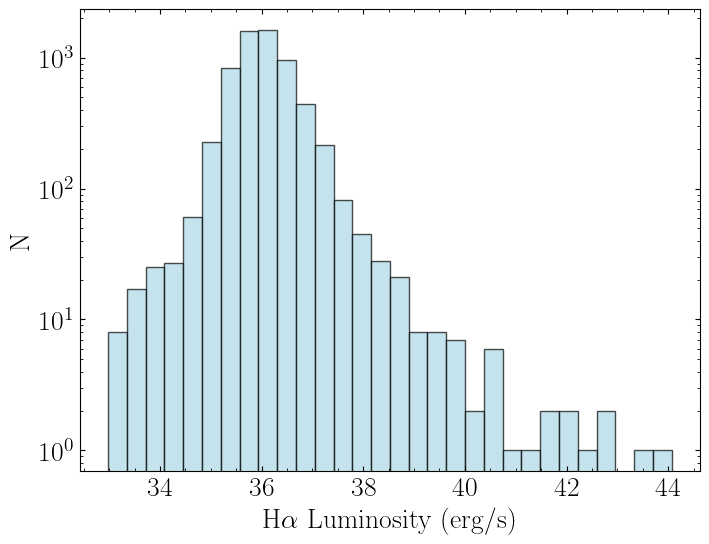

In [111]:
# plot the luminosity function
plt.figure(figsize=(8, 6))
plt.hist(np.log10(cat['L_Ha_sum_dered']), bins=30, color='lightblue', edgecolor='k', alpha = 0.7)
plt.xlabel(r'H$\alpha$ Luminosity (erg/s)')
plt.ylabel('N')
plt.yscale('log')
plt.minorticks_on()
# plt.grid(True, which='both', ls='--', lw=0.5)
plt.savefig('plots/M33_HII_luminosity_function.png', dpi=300, bbox_inches='tight')
plt.show()

Fit range: 36.00 <= log10(L) <= 40.00
Minimum bin count included: 0

Single power-law fit:
  log10(N) = a + b log10(L)
  a = 30.649
  b = -0.774
  RSS = 1.385, AIC = -113.269, BIC = -110.102

Broken power-law fit:
  a1      = 31.870
  b1      = -0.807
  b2      = -0.380
  x_break = 38.468
  RSS = 0.575, AIC = -140.940, BIC = -134.606

Preferred model:
  AIC prefers broken power law
  BIC prefers broken power law


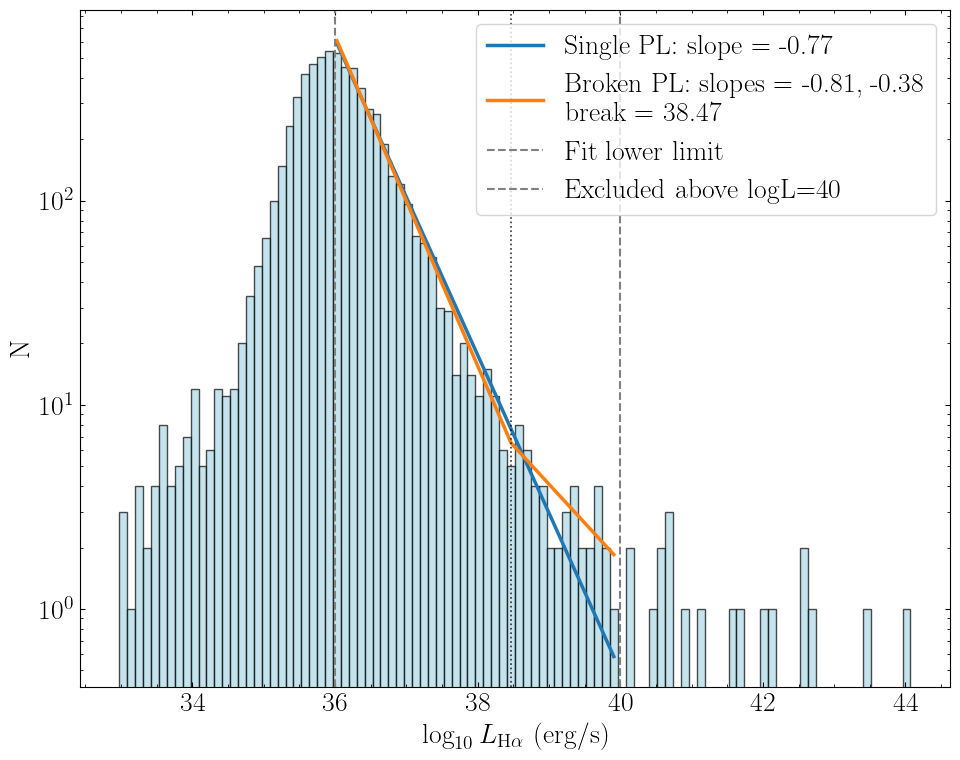

In [134]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# --------------------------------------------------
# models: fit in log-log space, plot in count space
# x = log10(L), y = log10(N_bin)
# --------------------------------------------------
def single_powerlaw_log(x, a, b):
    return a + b * x

def broken_powerlaw_log(x, a1, b1, b2, x_break):
    y = np.empty_like(x)
    left = x < x_break
    y[left] = a1 + b1 * x[left]

    y_break = a1 + b1 * x_break
    y[~left] = y_break + b2 * (x[~left] - x_break)
    return y

def fit_stats(y_true, y_pred, k):
    n = len(y_true)
    rss = np.sum((y_true - y_pred)**2)
    rss = max(rss, 1e-12)
    aic = n * np.log(rss / n) + 2 * k
    bic = n * np.log(rss / n) + k * np.log(n)
    return rss, aic, bic

# --------------------------------------------------
# data
# --------------------------------------------------
logL = np.log10(cat['L_Ha_sum_dered'])
logL = logL[np.isfinite(logL)]

# histogram setup
bins = 100
counts, edges = np.histogram(logL, bins=bins)
centers = 0.5 * (edges[:-1] + edges[1:])

# --------------------------------------------------
# fitting mask
# --------------------------------------------------
# choose lower limit for the tail fit
x_min_fit = np.percentile(logL, 50)   # or set manually, e.g. 37.2

# exclude very bright bins from fit
x_max_fit = 40

# also exclude sparse bins
min_bin_count = 0

fit_mask = (
    (centers >= x_min_fit) &
    (centers <= x_max_fit) &
    (counts >= min_bin_count)
)

x_fit = centers[fit_mask]
y_fit = np.log10(counts[fit_mask])

# Poisson uncertainty in log10(N)
sigma_fit = 1.0 / (np.log(10) * np.sqrt(counts[fit_mask]))

if len(x_fit) < 5:
    raise ValueError(
        "Not enough bins for fitting after masking. "
        "Try lowering x_min_fit, lowering min_bin_count, or increasing number of bins."
    )

# --------------------------------------------------
# single power-law fit
# --------------------------------------------------
p0_single = [np.max(y_fit), -1.0]
popt_single, pcov_single = curve_fit(
    single_powerlaw_log,
    x_fit, y_fit,
    p0=p0_single,
    sigma=sigma_fit,
    absolute_sigma=True,
    maxfev=20000
)

y_single_fit = single_powerlaw_log(x_fit, *popt_single)
rss1, aic1, bic1 = fit_stats(y_fit, y_single_fit, k=2)

# --------------------------------------------------
# broken power-law fit
# --------------------------------------------------
x_break0 = np.median(x_fit)
p0_broken = [np.max(y_fit), -0.5, -2.0, x_break0]

bounds = (
    [-np.inf, -10, -10, np.min(x_fit)],
    [ np.inf,  10,  10, np.max(x_fit)]
)

popt_broken, pcov_broken = curve_fit(
    broken_powerlaw_log,
    x_fit, y_fit,
    p0=p0_broken,
    bounds=bounds,
    sigma=sigma_fit,
    absolute_sigma=True,
    maxfev=50000
)

y_broken_fit = broken_powerlaw_log(x_fit, *popt_broken)
rss2, aic2, bic2 = fit_stats(y_fit, y_broken_fit, k=4)

# --------------------------------------------------
# report
# --------------------------------------------------
print(f"Fit range: {x_min_fit:.2f} <= log10(L) <= {x_max_fit:.2f}")
print(f"Minimum bin count included: {min_bin_count}")

print("\nSingle power-law fit:")
print(f"  log10(N) = a + b log10(L)")
print(f"  a = {popt_single[0]:.3f}")
print(f"  b = {popt_single[1]:.3f}")
print(f"  RSS = {rss1:.3f}, AIC = {aic1:.3f}, BIC = {bic1:.3f}")

print("\nBroken power-law fit:")
print(f"  a1      = {popt_broken[0]:.3f}")
print(f"  b1      = {popt_broken[1]:.3f}")
print(f"  b2      = {popt_broken[2]:.3f}")
print(f"  x_break = {popt_broken[3]:.3f}")
print(f"  RSS = {rss2:.3f}, AIC = {aic2:.3f}, BIC = {bic2:.3f}")

print("\nPreferred model:")
print("  AIC prefers broken power law" if aic2 < aic1 else "  AIC prefers single power law")
print("  BIC prefers broken power law" if bic2 < bic1 else "  BIC prefers single power law")

# --------------------------------------------------
# plot histogram with overplotted fits
# --------------------------------------------------
plt.figure(figsize=(10, 8))

# histogram
plt.hist(logL, bins=bins, color='lightblue', edgecolor='k', alpha=0.7)

# show fitted bins
# plt.scatter(
#     x_fit, counts[fit_mask],
#     color='k', s=35, zorder=5,
#     label='Bins used in fit'
# )

# smooth x grid over fit range only
x_line = np.linspace(np.min(x_fit), np.max(x_fit), 400)

# convert fitted log10(N) back to N for plotting on histogram
y_line_single = 10**single_powerlaw_log(x_line, *popt_single)
y_line_broken = 10**broken_powerlaw_log(x_line, *popt_broken)

plt.plot(
    x_line, y_line_single,
    lw=2.5,
    label=f'Single PL: slope = {popt_single[1]:.2f}'
)

plt.plot(
    x_line, y_line_broken,
    lw=2.5,
    label=(f'Broken PL: slopes = {popt_broken[1]:.2f}, {popt_broken[2]:.2f}\n'
           f'break = {popt_broken[3]:.2f}')
)

# mark fit limits
plt.axvline(x_min_fit, color='gray', ls='--', lw=1.5, label='Fit lower limit')
plt.axvline(x_max_fit, color='gray', ls='--', lw=1.5, label='Excluded above logL=40')
plt.axvline(popt_broken[3], color='k', ls=':', lw=1.2, alpha=0.8)

plt.xlabel(r'$\log_{10} L_{\mathrm{H}\alpha}$ (erg/s)')
plt.ylabel('N')
plt.yscale('log')
plt.minorticks_on()
plt.legend()
plt.tight_layout()
plt.savefig('plots/M33_HII_luminosity_function_with_overplotted_fits.png',
            dpi=300, bbox_inches='tight')
plt.show()

In [137]:
# import numpy as np
# import matplotlib.pyplot as plt
# from scipy.optimize import curve_fit
# from scipy.special import logsumexp

# # ============================================================
# # Santoro / Clauset-style continuous power-law fit
# # ============================================================

# def empirical_cdf(sorted_x):
#     """Empirical CDF evaluated at sorted data."""
#     n = len(sorted_x)
#     return np.arange(1, n + 1) / n

# def model_cdf_continuous_powerlaw(x, xmin, alpha):
#     """
#     Continuous power-law CDF for x >= xmin:
#         p(x) = (alpha - 1) * xmin^(alpha - 1) * x^(-alpha)
#     so
#         F(x) = 1 - (x/xmin)^(1-alpha)
#     """
#     return 1.0 - (x / xmin) ** (1.0 - alpha)

# def loglik_continuous_powerlaw(x, xmin, alpha):
#     """
#     Log-likelihood for continuous power law for data x >= xmin.
#     """
#     n = len(x)
#     if n == 0 or alpha <= 1 or xmin <= 0 or np.any(x < xmin):
#         return -np.inf
#     return n * np.log(alpha - 1.0) + n * (alpha - 1.0) * np.log(xmin) - alpha * np.sum(np.log(x))

# def ks_statistic_continuous_powerlaw(x, xmin, alpha):
#     """
#     KS statistic between empirical CDF and model CDF for x >= xmin.
#     """
#     x = np.sort(x)
#     F_emp = empirical_cdf(x)
#     F_model = model_cdf_continuous_powerlaw(x, xmin, alpha)
#     return np.max(np.abs(F_emp - F_model))

# def gaussian(x, A, mu, sigma):
#     return A * np.exp(-0.5 * ((x - mu) / sigma) ** 2)

# def fit_alpha_uncertainty_from_likelihood(x_tail, xmin, alpha_best, alpha_min=1.01, alpha_max=3.0, n_alpha_grid=1000):
#     """
#     Estimate alpha uncertainty by fitting a Gaussian to the relative likelihood
#     curve as a function of alpha, following the description you quoted.
#     """
#     alpha_grid = np.linspace(alpha_min, alpha_max, n_alpha_grid)
#     logL = np.array([loglik_continuous_powerlaw(x_tail, xmin, a) for a in alpha_grid])

#     # normalize likelihood safely
#     rel_like = np.exp(logL - np.max(logL))

#     # focus on region near the peak for stability
#     peak_mask = rel_like > 0.05
#     x_fit = alpha_grid[peak_mask]
#     y_fit = rel_like[peak_mask]

#     # fallback if peak region too small
#     if len(x_fit) < 10:
#         x_fit = alpha_grid
#         y_fit = rel_like

#     p0 = [1.0, alpha_best, 0.1]
#     bounds = ([0.0, alpha_min, 1e-4], [np.inf, alpha_max, 10.0])

#     try:
#         popt, pcov = curve_fit(gaussian, x_fit, y_fit, p0=p0, bounds=bounds, maxfev=20000)
#         _, mu, sigma = popt
#         return sigma, alpha_grid, rel_like, popt
#     except Exception:
#         # robust fallback: weighted std of the likelihood curve
#         w = rel_like / np.sum(rel_like)
#         mu = np.sum(w * alpha_grid)
#         sigma = np.sqrt(np.sum(w * (alpha_grid - mu)**2))
#         return sigma, alpha_grid, rel_like, None

# def santoro_powerlaw_fit(
#     L,
#     alpha_range=(1.01, 3.0),
#     n_alpha_grid=2000,
#     n_bootstrap=1000,
#     random_seed=42,
#     verbose=True
# ):
#     """
#     Fit luminosities with the Santoro / Clauset method described by the user.

#     Parameters
#     ----------
#     L : array-like
#         Luminosities in linear space (NOT log10).
#     alpha_range : tuple
#         Allowed alpha interval, default (1.01, 3.0).
#     n_alpha_grid : int
#         Number of alpha grid points for the likelihood search.
#     n_bootstrap : int
#         Number of bootstrap realizations for xmin uncertainty.
#     random_seed : int
#         RNG seed.
#     verbose : bool
#         Print summary.

#     Returns
#     -------
#     results : dict
#     """
#     rng = np.random.default_rng(random_seed)

#     # clean data
#     L = np.asarray(L, dtype=float)
#     L = L[np.isfinite(L)]
#     L = L[L > 0]
#     L = np.sort(L)

#     if len(L) < 20:
#         raise ValueError("Need at least ~20 positive luminosities for a meaningful power-law fit.")

#     # Santoro-style xmin search range: median ± 1 sigma
#     med = np.median(L)
#     sig = np.std(L, ddof=1)
#     xmin_lo = med - sig
#     xmin_hi = med + sig

#     # keep only empirical data points in that range as xmin candidates
#     xmin_candidates = L[(L >= xmin_lo) & (L <= xmin_hi)]
#     xmin_candidates = np.unique(xmin_candidates)

#     if len(xmin_candidates) == 0:
#         raise ValueError("No empirical Lmin candidates found within median ± 1σ.")

#     alpha_min, alpha_max = alpha_range
#     alpha_grid = np.linspace(alpha_min, alpha_max, n_alpha_grid)

#     fit_rows = []

#     # ------------------------------------------------------------
#     # For each candidate xmin:
#     #   1) keep tail x >= xmin
#     #   2) compute likelihood over alpha grid
#     #   3) choose alpha maximizing likelihood
#     #   4) compute KS
#     # ------------------------------------------------------------
#     print(f"Testing {len(xmin_candidates)} candidate Lmin values...")
#     for xmin in xmin_candidates:
#         x_tail = L[L >= xmin]
#         n_tail = len(x_tail)

#         # Need enough points above xmin
#         if n_tail < 10:
#             continue

#         logL_grid = np.array([loglik_continuous_powerlaw(x_tail, xmin, a) for a in alpha_grid])
#         i_best = np.argmax(logL_grid)
#         alpha_best_here = alpha_grid[i_best]
#         logL_best_here = logL_grid[i_best]
#         ks_here = ks_statistic_continuous_powerlaw(x_tail, xmin, alpha_best_here)

#         fit_rows.append({
#             "xmin": xmin,
#             "n_tail": n_tail,
#             "alpha": alpha_best_here,
#             "logL": logL_best_here,
#             "ks": ks_here,
#         })

#     if len(fit_rows) == 0:
#         raise ValueError("No valid fits found. Try checking the luminosity array or relaxing constraints.")

#     # choose model minimizing KS
#     fit_rows = sorted(fit_rows, key=lambda r: r["ks"])
#     best = fit_rows[0]

#     xmin_best = best["xmin"]
#     alpha_best = best["alpha"]
#     ks_best = best["ks"]
#     n_tail_best = best["n_tail"]

#     x_tail_best = L[L >= xmin_best]

#     # ------------------------------------------------------------
#     # Bootstrap uncertainty on xmin
#     # ------------------------------------------------------------
#     print(f"Computing bootstrap uncertainties with {n_bootstrap} realizations...")
#     bootstrap_xmins = []
#     bootstrap_alphas = []

#     for _ in range(n_bootstrap):
#         L_boot = rng.choice(L, size=len(L), replace=True)
#         L_boot = np.sort(L_boot)

#         med_b = np.median(L_boot)
#         sig_b = np.std(L_boot, ddof=1)
#         xmin_lo_b = med_b - sig_b
#         xmin_hi_b = med_b + sig_b

#         xmin_candidates_b = np.unique(L_boot[(L_boot >= xmin_lo_b) & (L_boot <= xmin_hi_b)])

#         best_b = None
#         for xmin_b in xmin_candidates_b:
#             x_tail_b = L_boot[L_boot >= xmin_b]
#             if len(x_tail_b) < 10:
#                 continue

#             logL_grid_b = np.array([loglik_continuous_powerlaw(x_tail_b, xmin_b, a) for a in alpha_grid])
#             i_best_b = np.argmax(logL_grid_b)
#             alpha_b = alpha_grid[i_best_b]
#             ks_b = ks_statistic_continuous_powerlaw(x_tail_b, xmin_b, alpha_b)

#             row_b = {"xmin": xmin_b, "alpha": alpha_b, "ks": ks_b}
#             if (best_b is None) or (ks_b < best_b["ks"]):
#                 best_b = row_b

#         if best_b is not None:
#             bootstrap_xmins.append(best_b["xmin"])
#             bootstrap_alphas.append(best_b["alpha"])

#     bootstrap_xmins = np.array(bootstrap_xmins)
#     bootstrap_alphas = np.array(bootstrap_alphas)

#     xmin_err = np.std(bootstrap_xmins, ddof=1) if len(bootstrap_xmins) > 1 else np.nan

#     # ------------------------------------------------------------
#     # Alpha uncertainty from Gaussian fit to likelihood curve
#     # at the best xmin
#     # ------------------------------------------------------------
#     alpha_err, alpha_likelihood_grid, rel_like, gaussian_fit = fit_alpha_uncertainty_from_likelihood(
#         x_tail_best, xmin_best, alpha_best,
#         alpha_min=alpha_min, alpha_max=alpha_max,
#         n_alpha_grid=1000
#     )

#     if verbose:
#         print("================================================")
#         print("Santoro / Clauset power-law fit")
#         print("================================================")
#         print(f"N total                = {len(L)}")
#         print(f"N used above Lmin      = {n_tail_best}")
#         print(f"Lmin search range      = [{xmin_lo:.3e}, {xmin_hi:.3e}]")
#         print(f"Best Lmin              = {xmin_best:.3e}")
#         print(f"Best alpha             = {alpha_best:.4f}")
#         print(f"KS statistic           = {ks_best:.4f}")
#         print(f"sigma(Lmin) bootstrap  = {xmin_err:.3e}")
#         print(f"sigma(alpha) likelihood= {alpha_err:.4f}")
#         print("================================================")

#     return {
#         "L": L,
#         "xmin_best": xmin_best,
#         "alpha_best": alpha_best,
#         "ks_best": ks_best,
#         "n_tail_best": n_tail_best,
#         "xmin_err": xmin_err,
#         "alpha_err": alpha_err,
#         "bootstrap_xmins": bootstrap_xmins,
#         "bootstrap_alphas": bootstrap_alphas,
#         "fit_rows": fit_rows,
#         "alpha_likelihood_grid": alpha_likelihood_grid,
#         "alpha_relative_likelihood": rel_like,
#         "alpha_gaussian_fit": gaussian_fit,
#         "xmin_search_range": (xmin_lo, xmin_hi),
#     }

# # ============================================================
# # Plotting helpers
# # ============================================================

# def plot_santoro_ccdf(results, outfile=None):
#     """
#     Plot empirical CCDF and best-fit model.
#     """
#     L = results["L"]
#     xmin = results["xmin_best"]
#     alpha = results["alpha_best"]

#     # empirical CCDF
#     x = np.sort(L)
#     ccdf_emp = 1.0 - (np.arange(1, len(x)+1) / len(x)) + 1/len(x)

#     # tail only
#     x_tail = x[x >= xmin]
#     n_tail = len(x_tail)
#     ccdf_tail_emp = 1.0 - (np.arange(1, n_tail+1) / n_tail) + 1/n_tail

#     # model CCDF for x >= xmin
#     x_model = np.logspace(np.log10(xmin), np.log10(np.max(x_tail)), 300)
#     ccdf_model = (x_model / xmin) ** (1.0 - alpha)

#     plt.figure(figsize=(7, 6))
#     plt.loglog(x, ccdf_emp, 'o', ms=4, alpha=0.5, label='Empirical CCDF (all data)')
#     plt.loglog(x_tail, ccdf_tail_emp, 'o', ms=4, label='Empirical CCDF (L ≥ Lmin)')
#     plt.loglog(x_model, ccdf_model, lw=2.5, label=fr'Best fit: $\alpha={alpha:.2f}$')

#     plt.axvline(xmin, color='k', ls='--', lw=1.5, label=fr'$L_{{\min}}={xmin:.2e}$')
#     plt.xlabel(r'$L_{\mathrm{H}\alpha}$ (erg s$^{-1}$)')
#     plt.ylabel(r'$P(L^\prime \geq L)$')
#     plt.legend()
#     plt.minorticks_on()
#     plt.tight_layout()

#     if outfile is not None:
#         plt.savefig(outfile, dpi=300, bbox_inches='tight')
#     plt.show()

# def plot_santoro_histogram_with_tail_model(results, bins=30, outfile=None):
#     """
#     Plot histogram in logL, and overplot the implied model tail.
#     This is for visualization only; the fit itself is unbinned.
#     """
#     L = results["L"]
#     xmin = results["xmin_best"]
#     alpha = results["alpha_best"]

#     logL = np.log10(L)
#     counts, edges = np.histogram(logL, bins=bins)
#     centers = 0.5 * (edges[:-1] + edges[1:])
#     dlogL = np.diff(edges)

#     # Build expected differential counts from the best-fit model.
#     # Use the observed number of points above xmin to normalize.
#     n_tail = np.sum(L >= xmin)

#     # convert histogram bin edges from logL to L
#     L_edges = 10**edges

#     model_counts = np.zeros_like(counts, dtype=float)

#     for i in range(len(counts)):
#         L1 = L_edges[i]
#         L2 = L_edges[i+1]

#         if L2 <= xmin:
#             model_counts[i] = np.nan
#             continue

#         # clip lower edge to xmin for the power-law tail
#         L1_eff = max(L1, xmin)

#         # Integral of normalized PDF over [L1_eff, L2]
#         # p(L) = (alpha-1) xmin^(alpha-1) L^(-alpha)
#         prob = (xmin**(alpha - 1.0)) * (L1_eff**(1.0 - alpha) - L2**(1.0 - alpha))
#         model_counts[i] = n_tail * prob

#     plt.figure(figsize=(8, 6))
#     plt.hist(logL, bins=bins, color='lightblue', edgecolor='k', alpha=0.7, label='Data')
#     plt.plot(centers, model_counts, lw=2.5, label=fr'Unbinned PL fit: $\alpha={alpha:.2f}$')
#     plt.axvline(np.log10(xmin), color='k', ls='--', lw=1.5, label=fr'$\log L_{{\min}}={np.log10(xmin):.2f}$')

#     plt.xlabel(r'$\log_{10} L_{\mathrm{H}\alpha}$ (erg/s)')
#     plt.ylabel('Number of Regions')
#     plt.yscale('log')
#     plt.minorticks_on()
#     plt.legend()
#     plt.tight_layout()

#     if outfile is not None:
#         plt.savefig(outfile, dpi=300, bbox_inches='tight')
#     plt.show()

# def plot_alpha_likelihood(results, outfile=None):
#     """
#     Plot relative likelihood vs alpha and the Gaussian fit used for sigma(alpha).
#     """
#     alpha_grid = results["alpha_likelihood_grid"]
#     rel_like = results["alpha_relative_likelihood"]
#     gfit = results["alpha_gaussian_fit"]

#     plt.figure(figsize=(7, 5))
#     plt.plot(alpha_grid, rel_like, lw=2, label='Relative likelihood')

#     if gfit is not None:
#         plt.plot(alpha_grid, gaussian(alpha_grid, *gfit), '--', lw=2,
#                  label=fr'Gaussian fit ($\sigma_\alpha={gfit[2]:.3f}$)')

#     plt.axvline(results["alpha_best"], color='k', ls=':', label=fr'Best $\alpha={results["alpha_best"]:.3f}$')
#     plt.xlabel(r'$\alpha$')
#     plt.ylabel('Relative likelihood')
#     plt.legend()
#     plt.tight_layout()

#     if outfile is not None:
#         plt.savefig(outfile, dpi=300, bbox_inches='tight')
#     plt.show()

# # ============================================================
# # Example usage on your catalog
# # ============================================================

# # Use linear luminosities, not log10 luminosities
# L = np.asarray(cat['L_Ha_sum_dered'], dtype=float)

# results = santoro_powerlaw_fit(
#     L,
#     alpha_range=(1.01, 3.0),
#     n_alpha_grid=2000,
#     n_bootstrap=10,
#     random_seed=42,
#     verbose=True
# )

# print(f"\nFinal result:")
# print(f"Lmin  = {results['xmin_best']:.3e} +/- {results['xmin_err']:.3e}")
# print(f"alpha = {results['alpha_best']:.3f} +/- {results['alpha_err']:.3f}")
# print(f"KS    = {results['ks_best']:.4f}")

# # plots
# plot_santoro_ccdf(results, outfile='plots/M33_HII_powerlaw_CCDF_fit.png')
# plot_santoro_histogram_with_tail_model(results, bins=30,
#                                        outfile='plots/M33_HII_hist_with_unbinned_powerlaw_fit.png')
# plot_alpha_likelihood(results, outfile='plots/M33_HII_alpha_likelihood.png')

In [260]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# ------------------------------------------------------------
# Helpers
# ------------------------------------------------------------
def empirical_cdf(sorted_x):
    n = len(sorted_x)
    return np.arange(1, n + 1) / n

def model_cdf_continuous_powerlaw(x, xmin, alpha):
    # valid for x >= xmin, alpha > 1
    return 1.0 - (x / xmin) ** (1.0 - alpha)

def ks_statistic_continuous_powerlaw(sorted_x, xmin, alpha):
    F_emp = empirical_cdf(sorted_x)
    F_model = model_cdf_continuous_powerlaw(sorted_x, xmin, alpha)
    return np.max(np.abs(F_emp - F_model))

def mle_alpha_continuous_powerlaw(x_tail, xmin):
    """
    Closed-form MLE for continuous power law:
        p(x) = (alpha-1) xmin^(alpha-1) x^(-alpha), x >= xmin
    """
    n = len(x_tail)
    s = np.sum(np.log(x_tail / xmin))
    if s <= 0:
        return np.nan
    return 1.0 + n / s

def gaussian(x, A, mu, sigma):
    return A * np.exp(-0.5 * ((x - mu) / sigma) ** 2)

# ------------------------------------------------------------
# Fast Santoro / Clauset fit
# ------------------------------------------------------------
def santoro_powerlaw_fit_fast(
    L,
    alpha_range=(1.0, 3.0),
    xmin_stride=5,
    min_tail_n=30,
    n_bootstrap=0,
    random_seed=42,
    verbose=True
):
    """
    Fast unbinned power-law fit:
    - candidate xmin from empirical points within median ± 1 sigma
    - alpha from closed-form MLE (no alpha grid search)
    - choose best model by minimum KS
    - optional bootstrap for xmin uncertainty

    Parameters
    ----------
    L : array-like
        Linear luminosities.
    alpha_range : tuple
        Allowed range of alpha, e.g. (1.0, 3.0)
    xmin_stride : int
        Only test every xmin_stride-th candidate xmin for speed.
    min_tail_n : int
        Minimum number of points above xmin.
    n_bootstrap : int
        Number of bootstrap runs. Set 0 for speed while testing.
    """
    rng = np.random.default_rng(random_seed)

    L = np.asarray(L, dtype=float)
    L = L[np.isfinite(L)]
    L = L[L > 0]
    L = np.sort(L)

    if len(L) < min_tail_n:
        raise ValueError("Not enough positive luminosities.")

    alpha_min, alpha_max = alpha_range

    # search window for xmin
    med = np.median(L)
    sig = np.std(L, ddof=1)
    xmin_lo = med - sig
    xmin_hi = med + sig

    xmin_candidates = np.unique(L[(L >= xmin_lo) & (L <= xmin_hi)])
    if len(xmin_candidates) == 0:
        raise ValueError("No xmin candidates found in median ± 1 sigma range.")

    # stride for speed
    xmin_candidates = xmin_candidates[::xmin_stride]

    best = None
    fit_rows = []

    # Because L is sorted, we can use searchsorted instead of repeated masking
    for xmin in xmin_candidates:
        i0 = np.searchsorted(L, xmin, side='left')
        x_tail = L[i0:]
        n_tail = len(x_tail)

        if n_tail < min_tail_n:
            continue

        alpha = mle_alpha_continuous_powerlaw(x_tail, xmin)
        if not np.isfinite(alpha):
            continue
        if not (alpha_min <= alpha <= alpha_max):
            continue

        ks = ks_statistic_continuous_powerlaw(x_tail, xmin, alpha)

        row = {
            "xmin": xmin,
            "alpha": alpha,
            "ks": ks,
            "n_tail": n_tail
        }
        fit_rows.append(row)

        if (best is None) or (ks < best["ks"]):
            best = row

    if best is None:
        raise ValueError("No valid fit found. Try decreasing xmin_stride or min_tail_n.")

    # --------------------------------------------------------
    # bootstrap xmin uncertainty
    # --------------------------------------------------------
    bootstrap_xmins = []
    bootstrap_alphas = []

    if n_bootstrap > 0:
        for _ in range(n_bootstrap):
            Lb = rng.choice(L, size=len(L), replace=True)
            Lb.sort()

            med_b = np.median(Lb)
            sig_b = np.std(Lb, ddof=1)
            xmin_lo_b = med_b - sig_b
            xmin_hi_b = med_b + sig_b

            xmin_candidates_b = np.unique(Lb[(Lb >= xmin_lo_b) & (Lb <= xmin_hi_b)])
            xmin_candidates_b = xmin_candidates_b[::xmin_stride]

            best_b = None
            for xmin_b in xmin_candidates_b:
                i0_b = np.searchsorted(Lb, xmin_b, side='left')
                x_tail_b = Lb[i0_b:]
                n_tail_b = len(x_tail_b)

                if n_tail_b < min_tail_n:
                    continue

                alpha_b = mle_alpha_continuous_powerlaw(x_tail_b, xmin_b)
                if not np.isfinite(alpha_b):
                    continue
                if not (alpha_min <= alpha_b <= alpha_max):
                    continue

                ks_b = ks_statistic_continuous_powerlaw(x_tail_b, xmin_b, alpha_b)

                if (best_b is None) or (ks_b < best_b["ks"]):
                    best_b = {"xmin": xmin_b, "alpha": alpha_b, "ks": ks_b}

            if best_b is not None:
                bootstrap_xmins.append(best_b["xmin"])
                bootstrap_alphas.append(best_b["alpha"])

    bootstrap_xmins = np.array(bootstrap_xmins)
    bootstrap_alphas = np.array(bootstrap_alphas)

    xmin_err = np.std(bootstrap_xmins, ddof=1) if len(bootstrap_xmins) > 1 else np.nan

    if verbose:
        print("Fast Santoro/Clauset fit")
        print(f"N total           = {len(L)}")
        print(f"Best xmin         = {best['xmin']:.3e}")
        print(f"Best alpha        = {best['alpha']:.4f}")
        print(f"Best KS           = {best['ks']:.4f}")
        print(f"N above xmin      = {best['n_tail']}")
        print(f"xmin uncertainty  = {xmin_err:.3e}")
        print(f"Candidates tested = {len(fit_rows)}")

    return {
        "L": L,
        "xmin_best": best["xmin"],
        "alpha_best": best["alpha"],
        "ks_best": best["ks"],
        "n_tail_best": best["n_tail"],
        "xmin_err": xmin_err,
        "bootstrap_xmins": bootstrap_xmins,
        "bootstrap_alphas": bootstrap_alphas,
        "fit_rows": fit_rows,
        "xmin_search_range": (xmin_lo, xmin_hi),
    }

# ------------------------------------------------------------
# Optional alpha uncertainty from likelihood curve at best xmin
# This part is cheap because it's only done once.
# ------------------------------------------------------------
def alpha_uncertainty_from_likelihood(
    L, xmin, alpha_best, alpha_range=(1.0, 3.0), n_alpha_grid=400
):
    x_tail = np.sort(L[L >= xmin])
    alpha_grid = np.linspace(alpha_range[0], alpha_range[1], n_alpha_grid)

    n = len(x_tail)
    sum_logx = np.sum(np.log(x_tail))
    log_xmin = np.log(xmin)

    # vectorized log-likelihood
    # logL = n*log(alpha-1) + n*(alpha-1)*log(xmin) - alpha*sum(log x)
    valid = alpha_grid > 1
    logL = np.full_like(alpha_grid, -np.inf, dtype=float)
    a = alpha_grid[valid]
    logL[valid] = n * np.log(a - 1.0) + n * (a - 1.0) * log_xmin - a * sum_logx

    rel_like = np.exp(logL - np.nanmax(logL))

    peak_mask = rel_like > 0.05
    x_fit = alpha_grid[peak_mask]
    y_fit = rel_like[peak_mask]

    if len(x_fit) < 5:
        x_fit = alpha_grid[valid]
        y_fit = rel_like[valid]

    p0 = [1.0, alpha_best, 0.1]
    bounds = ([0.0, alpha_range[0], 1e-4], [np.inf, alpha_range[1], 10.0])

    try:
        popt, _ = curve_fit(gaussian, x_fit, y_fit, p0=p0, bounds=bounds, maxfev=10000)
        sigma_alpha = popt[2]
    except Exception:
        w = rel_like[valid] / np.sum(rel_like[valid])
        mu = np.sum(w * alpha_grid[valid])
        sigma_alpha = np.sqrt(np.sum(w * (alpha_grid[valid] - mu)**2))
        popt = None

    return sigma_alpha, alpha_grid, rel_like, popt

# ------------------------------------------------------------
# Visualization: overplot unbinned fit on histogram
# ------------------------------------------------------------
def plot_histogram_with_unbinned_powerlaw_fit(results, bins=30, outfile=None):
    L = results["L"]
    xmin = results["xmin_best"]
    alpha = results["alpha_best"]

    logL = np.log10(L)
    counts, edges = np.histogram(logL, bins=bins)
    centers = 0.5 * (edges[:-1] + edges[1:])

    n_tail = np.sum(L >= xmin)
    L_edges = 10**edges

    model_counts = np.full_like(counts, np.nan, dtype=float)

    for i in range(len(counts)):
        L1 = L_edges[i]
        L2 = L_edges[i + 1]

        if L2 <= xmin:
            continue

        L1_eff = max(L1, xmin)
        prob = (xmin ** (alpha - 1.0)) * (L1_eff ** (1.0 - alpha) - L2 ** (1.0 - alpha))
        model_counts[i] = n_tail * prob

    plt.figure(figsize=(8, 6))
    plt.hist(logL, bins=bins, color=colors[0], edgecolor='k', alpha=0.7)
    plt.plot(centers, model_counts, lw=2.5, color= 'k',
             label=fr'Unbinned PL fit: $\alpha={alpha:.2f}$')
    plt.axvline(np.log10(xmin), color='k', ls='--', lw=1.5,
                label=fr'$\log L_{{\min}}={np.log10(xmin):.2f}$')

    plt.xlabel(r'$\log_{10} L_{\mathrm{H}\alpha}$ (erg/s)')
    plt.ylabel('Number of Regions')
    plt.yscale('log')
    plt.minorticks_on()
    plt.legend()
    plt.ylim(0.8,)
    plt.tight_layout()

    if outfile is not None:
        plt.savefig(outfile, dpi=300, bbox_inches='tight')
    plt.show()

Fast Santoro/Clauset fit
N total           = 6266
Best xmin         = 7.504e+35
Best alpha        = 1.7341
Best KS           = 0.0302
N above xmin      = 3766
xmin uncertainty  = 1.347e+35
Candidates tested = 624
alpha uncertainty ~ 0.012


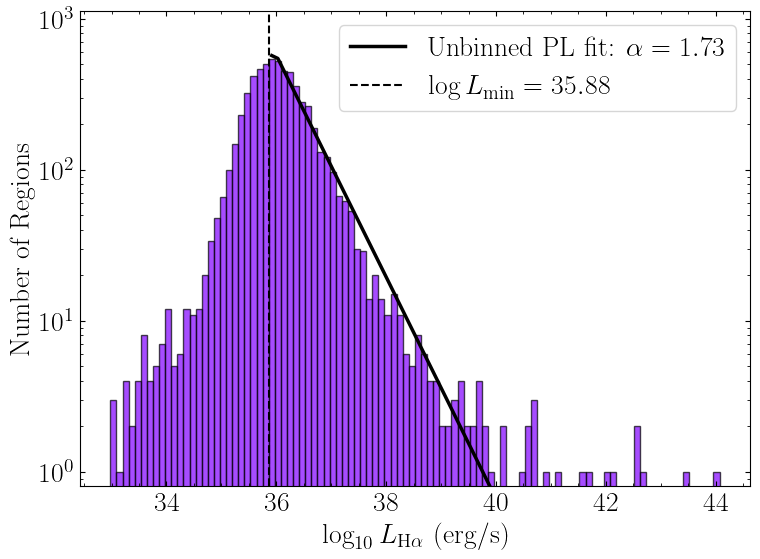

In [261]:
L = np.asarray(cat['L_Ha_sum_dered'], dtype=float)

results = santoro_powerlaw_fit_fast(
    L,
    alpha_range=(0.0, 3.0),
    xmin_stride=10,   # bigger = faster
    min_tail_n=30,
    n_bootstrap=10,    # keep at 0 while testing
    verbose=True
)

sigma_alpha, alpha_grid, rel_like, gfit = alpha_uncertainty_from_likelihood(
    results["L"],
    results["xmin_best"],
    results["alpha_best"],
    alpha_range=(1.0, 3.0),
    n_alpha_grid=400
)

print(f"alpha uncertainty ~ {sigma_alpha:.3f}")

plot_histogram_with_unbinned_powerlaw_fit(
    results,
    bins=100,
    outfile='plots/M33_HII_hist_with_fast_unbinned_powerlaw_fit.png'
)